# Activity Cliff-aware ΔpKi 예측 파이프라인

한 곳만 다른 분자쌍 (A, B)를 받아 **Δ = p(B) − p(A)** 를 직접 예측한다.
3D CNN 인코더는 별도로 개발하고, 여기서는 그 앞뒤(입력 · 손실 · 평가 · 설명)를 만든다.

| AC-aware 아이디어 | 구현 |
|---|---|
| ① 표현 | 두 분자 + 바뀐 조각 + 편집 종류 + 타깃 정보 |
| ② 손실 | 차이가 큰 쌍에 가중치를 더 준다 |
| ③ 설명 | 원자별 기여도 (미구현) |
| ④ 평가 | 난이도 × cliff 여부로 쪼개서 본다 |

In [1]:
import os, urllib.request
from multiprocessing import Pool
import numpy as np, pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFMCS, rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')

DATA, PAIRS = 'data/moleculeace', 'data/pairs'
# 개발용: 작고 cliff 비율 높은 타깃 4개 (Ki 2 + EC50 2). 괜찮으면 30개로 늘린다
# CHEMBL2835_Ki는 쌍은 많지만 cliff 2%라 제외
DEV_TARGETS = ['CHEMBL1862_Ki', 'CHEMBL237_EC50', 'CHEMBL4616_EC50', 'CHEMBL2034_Ki']
USE_ALL_TARGETS = True  # True면 3번 셀에서 30개 전체로 바꾼다
SEED = 0
SEEDS = [0, 1, 2]       # 실행 간 편차를 재려면 시드가 여러 개여야 한다
CLIFF = 1.0         # |Δ| >= 1 → cliff (MoleculeACE 기준, 10배)
VAL_FRAC = 0.2      # train 분자 중 validation 비율
SIM_MIN = 0.5       # ECFP4 Tanimoto 사전 필터 (MCS 통과 쌍의 99.5% 유지)
MAX_CHANGED = 10    # 한쪽에서 바뀐 원자 수 상한 (MMP 관례)
MCS_TIMEOUT = 1     # 초. 2초로 늘려도 통과 쌍 거의 같음
EXPAND_TRAIN = True # 학습 쌍을 유사도 조건만 만족하는 쌍 전부로 확대 (SQRL 방식). 평가 쌍은 그대로
N_JOBS = 64
os.makedirs(DATA, exist_ok=True); os.makedirs(PAIRS, exist_ok=True)

## 1. 데이터

MoleculeACE 벤치마크의 ChEMBL 타깃 30개를 모두 내려받는다.
활성값은 −log10(M) 단위라 Δ는 로그 단위의 차이가 된다.

In [2]:
URL = 'https://raw.githubusercontent.com/molML/MoleculeACE/main/MoleculeACE/Data/benchmark_data/'
TARGETS = ['CHEMBL1862_Ki', 'CHEMBL1871_Ki', 'CHEMBL2034_Ki', 'CHEMBL2047_EC50', 'CHEMBL204_Ki', 'CHEMBL2147_Ki',
           'CHEMBL214_Ki', 'CHEMBL218_EC50', 'CHEMBL219_Ki', 'CHEMBL228_Ki', 'CHEMBL231_Ki', 'CHEMBL233_Ki',
           'CHEMBL234_Ki', 'CHEMBL235_EC50', 'CHEMBL236_Ki', 'CHEMBL237_EC50', 'CHEMBL237_Ki', 'CHEMBL238_Ki',
           'CHEMBL239_EC50', 'CHEMBL244_Ki', 'CHEMBL262_Ki', 'CHEMBL264_Ki', 'CHEMBL2835_Ki', 'CHEMBL287_Ki',
           'CHEMBL2971_Ki', 'CHEMBL3979_EC50', 'CHEMBL4005_Ki', 'CHEMBL4203_Ki', 'CHEMBL4616_EC50', 'CHEMBL4792_Ki']
for t in TARGETS:
    if not os.path.exists(f'{DATA}/{t}.csv'):
        urllib.request.urlretrieve(f'{URL}{t}.csv', f'{DATA}/{t}.csv')
if USE_ALL_TARGETS:
    DEV_TARGETS = TARGETS
print(f'사용 타깃 {len(DEV_TARGETS)}개')
pd.Series({t: len(pd.read_csv(f'{DATA}/{t}.csv')) for t in TARGETS}, name='n_mols').sort_values().to_frame().T

사용 타깃 30개


,CHEMBL2835_Ki,CHEMBL2047_EC50,CHEMBL1871_Ki,CHEMBL4616_EC50,CHEMBL4203_Ki,CHEMBL2034_Ki,CHEMBL1862_Ki,CHEMBL262_Ki,CHEMBL237_EC50,CHEMBL4005_Ki,...,CHEMBL219_Ki,CHEMBL235_EC50,CHEMBL236_Ki,CHEMBL237_Ki,CHEMBL204_Ki,CHEMBL264_Ki,CHEMBL244_Ki,CHEMBL233_Ki,CHEMBL214_Ki,CHEMBL234_Ki
n_mols,615,631,659,682,731,750,794,856,955,960,...,1865,2349,2598,2603,2754,2862,3097,3142,3317,3657


## 2. 분자 split

하이퍼파라미터를 평가 세트로 고르면 성능이 부풀려지므로, 학습용 분자의 일부를 검증용으로 뗀다.
**분자 단위로 나누기 때문에 쌍의 난이도는 두 분자가 각각 어디에 속하는지로 정해진다.**

| 쌍 난이도 | 두 분자 | 의미 |
|---|---|---|
| train | 둘 다 학습 | 학습용 |
| easy | 한쪽만 학습 | 한 분자는 본 적 있음 |
| hard | 둘 다 미지 | 둘 다 처음 |

검증용과 평가용이 섞인 쌍은 어느 쪽에도 속하지 않아 버린다.

In [3]:
from functools import lru_cache

@lru_cache(maxsize=None)   # 30개 타깃이면 load가 수십 번 불린다
def load(target):
    df = pd.read_csv(f'{DATA}/{target}.csv').rename(columns={'y [pEC50/pKi]': 'p'})[['smiles', 'p', 'cliff_mol', 'split']]
    train = df.index[df.split == 'train']
    rng = np.random.default_rng(SEED)
    # ponytail: 단순 무작위 추출. val 결과가 흔들리면 cliff_mol 기준 층화 추출로 바꾼다
    df.loc[rng.choice(train, int(len(train) * VAL_FRAC), replace=False), 'split'] = 'val'
    return df

pd.DataFrame({t: load(t).split.value_counts() for t in DEV_TARGETS}).T.head(10)

split,train,test,val
CHEMBL1862_Ki,507,161,126
CHEMBL1871_Ki,420,134,105
CHEMBL2034_Ki,479,152,119
CHEMBL2047_EC50,403,128,100
CHEMBL204_Ki,1761,553,440
CHEMBL2147_Ki,930,294,232
CHEMBL214_Ki,2121,666,530
CHEMBL218_EC50,659,208,164
CHEMBL219_Ki,1193,374,298
CHEMBL228_Ki,1090,342,272


## 3. "한 곳만 다른 쌍" 정의

두 분자의 최대 공통 부분구조를 구하고, 거기 들지 않은 원자를 **바뀐 원자**로 본다.
세 조건을 모두 만족해야 인정한다.

1. 바뀐 원자가 각 분자에서 **연결된 한 덩어리**일 것
2. 양쪽 다 바뀌었으면 **같은 자리에 붙어 있을 것**
3. 바뀐 원자 수가 상한 이하일 것

편집 종류는 A → B 방향으로 정한다. 양쪽 다 바뀌면 **replace**, A에만 없으면 **insert**, B에만 없으면 **delete**.

고리는 "고리 결합끼리만" 매칭한다. 고리 전체 일치를 요구하면 고리 원자 하나 치환이 고리 통째 교체로 잡히고 느려진다.
2D 구조가 같고 입체만 다른 쌍은 제외한다.

In [4]:
def n_components(mol, atoms):
    left, n = set(atoms), 0
    while left:
        n += 1
        stack = [left.pop()]
        while stack:
            for nb in mol.GetAtomWithIdx(stack.pop()).GetNeighbors():
                if nb.GetIdx() in left:
                    left.remove(nb.GetIdx()); stack.append(nb.GetIdx())
    return n

def anchors(mol, changed, match):
    """바뀐 원자에 붙은 MCS 원자를 MCS 쿼리 내 순번으로 반환"""
    pos = {x: k for k, x in enumerate(match)}
    return {pos[nb.GetIdx()] for a in changed for nb in mol.GetAtomWithIdx(a).GetNeighbors() if nb.GetIdx() in pos}

def single_site(sa, sb):
    """한 곳만 다르면 (edit, atoms_a, atoms_b), 아니면 탈락 사유 문자열"""
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    if r.canceled:
        return 'timeout'
    q = Chem.MolFromSmarts(r.smartsString)
    ma = a.GetSubstructMatch(q)
    ca = [i for i in range(a.GetNumAtoms()) if i not in ma]
    # 대칭 분자는 매칭이 여러 개라 anchor 순번이 달라질 수 있어 B의 매칭을 모두 확인
    for mb in b.GetSubstructMatches(q, uniquify=False, maxMatches=1000):
        cb = [i for i in range(b.GetNumAtoms()) if i not in mb]
        if not ca and not cb:
            return 'identical_2d'
        if max(len(ca), len(cb)) > MAX_CHANGED:
            return 'too_big'
        if n_components(a, ca) > 1 or n_components(b, cb) > 1:
            continue
        if not ca or not cb or anchors(a, ca, ma) == anchors(b, cb, mb):
            return ('insert' if not ca else 'delete' if not cb else 'replace'), ca, cb
    return 'multi_site'

In [5]:
# 판정 규칙 확인
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1')[0] == 'replace'  # 치환기 교체
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(F)cc1')[0] == 'insert'      # H → F
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1')[0] == 'delete'      # F → H
assert single_site('Cc1ccccc1', 'Cc1ccncc1')[0] == 'replace'                     # 고리 원자 C → N
assert single_site('Fc1ccc(Cl)cc1', 'Nc1ccc(Br)cc1') == 'multi_site'             # 두 곳 변경
assert single_site('C[C@H](N)O', 'C[C@@H](N)O') == 'identical_2d'                # 입체만 다름
single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(OC)cc1')

('replace', [8], [8, 9])

## 4. 쌍 생성

공통 부분구조 계산이 비싸므로 지문 유사도로 후보를 먼저 거른 뒤 병렬로 판정한다.
결과는 캐시하므로, 판정 기준을 바꾸면 캐시를 지우고 다시 돌려야 한다.

쌍은 한 방향으로만 저장한다. 역방향은 학습할 때 추가한다.

In [6]:
FPGEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
PAIR_SPLIT = {('train', 'train'): 'train', ('train', 'val'): 'val_easy', ('val', 'val'): 'val_hard',
              ('test', 'train'): 'test_easy', ('test', 'test'): 'test_hard'}

def _job(args):
    i, j, sa, sb = args
    try:
        return i, j, single_site(sa, sb)
    except Exception:
        return i, j, 'error'

def make_pairs(target):
    path = f'{PAIRS}/{target}.pkl'
    if os.path.exists(path):
        cached = pd.read_pickle(path)
        print(f'{target}: 캐시 {len(cached)}쌍 (cliff {cached.is_cliff.sum()})')
        return cached
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    cand = [(i, j) for i in range(len(df))
            for j, s in enumerate(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]), i + 1) if s >= SIM_MIN]
    cand = [(i, j) for i, j in cand if tuple(sorted((df.split[i], df.split[j]))) in PAIR_SPLIT]
    with Pool(N_JOBS) as pool:
        res = pool.map(_job, [(i, j, df.smiles[i], df.smiles[j]) for i, j in cand], chunksize=20)

    rows = []
    for i, j, r in res:
        if isinstance(r, str):
            continue
        edit, ca, cb = r
        a, b = Chem.MolFromSmiles(df.smiles[i]), Chem.MolFromSmiles(df.smiles[j])
        rows.append(dict(i=i, j=j, smiles_a=df.smiles[i], smiles_b=df.smiles[j], p_a=df.p[i], p_b=df.p[j],
                         delta=df.p[j] - df.p[i], edit=edit, atoms_a=ca, atoms_b=cb,
                         frag_a=Chem.MolFragmentToSmiles(a, ca) if ca else '',
                         frag_b=Chem.MolFragmentToSmiles(b, cb) if cb else '',
                         split=PAIR_SPLIT[tuple(sorted((df.split[i], df.split[j])))]))
    pairs = pd.DataFrame(rows)
    pairs['is_cliff'] = pairs.delta.abs() >= CLIFF
    pairs.to_pickle(path)
    print(f'{target}: 후보 {len(cand)} → {len(pairs)}쌍 (cliff {pairs.is_cliff.sum()})',
          pd.Series([r for _, _, r in res if isinstance(r, str)]).value_counts().to_dict())
    return pairs

pairs = pd.concat([make_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True)
# 각 분자가 속한 split (쌍 split의 근거)
mol_split = {t: load(t).split for t in DEV_TARGETS}
pairs['split_a'] = [mol_split[t][i] for t, i in zip(pairs.target, pairs.i)]
pairs['split_b'] = [mol_split[t][j] for t, j in zip(pairs.target, pairs.j)]

CHEMBL1862_Ki: 캐시 6892쌍 (cliff 2909)
CHEMBL1871_Ki: 캐시 1352쌍 (cliff 249)
CHEMBL2034_Ki: 캐시 2009쌍 (cliff 385)
CHEMBL2047_EC50: 캐시 1695쌍 (cliff 298)
CHEMBL204_Ki: 캐시 6632쌍 (cliff 2017)
CHEMBL2147_Ki: 캐시 5605쌍 (cliff 2002)
CHEMBL214_Ki: 캐시 6708쌍 (cliff 1176)
CHEMBL218_EC50: 캐시 1763쌍 (cliff 526)
CHEMBL219_Ki: 캐시 3444쌍 (cliff 833)
CHEMBL228_Ki: 캐시 3249쌍 (cliff 709)
CHEMBL231_Ki: 캐시 2592쌍 (cliff 601)
CHEMBL233_Ki: 캐시 10416쌍 (cliff 2408)
CHEMBL234_Ki: 캐시 17767쌍 (cliff 2243)
CHEMBL235_EC50: 캐시 4449쌍 (cliff 1000)
CHEMBL236_Ki: 캐시 8269쌍 (cliff 1886)
CHEMBL237_EC50: 캐시 3283쌍 (cliff 1422)
CHEMBL237_Ki: 캐시 10021쌍 (cliff 2818)
CHEMBL238_Ki: 캐시 1776쌍 (cliff 363)
CHEMBL239_EC50: 캐시 3029쌍 (cliff 750)


CHEMBL244_Ki: 캐시 10363쌍 (cliff 2703)
CHEMBL262_Ki: 캐시 978쌍 (cliff 221)
CHEMBL264_Ki: 캐시 10021쌍 (cliff 2126)
CHEMBL2835_Ki: 캐시 8061쌍 (cliff 185)
CHEMBL287_Ki: 캐시 3614쌍 (cliff 1047)
CHEMBL2971_Ki: 캐시 8502쌍 (cliff 388)
CHEMBL3979_EC50: 캐시 1984쌍 (cliff 364)
CHEMBL4005_Ki: 캐시 3529쌍 (cliff 772)
CHEMBL4203_Ki: 캐시 389쌍 (cliff 72)
CHEMBL4616_EC50: 캐시 2092쌍 (cliff 594)
CHEMBL4792_Ki: 캐시 3485쌍 (cliff 922)


## 4-1. 학습 쌍 확대

단일 부위 쌍만 쓰면 학습량이 부족해 모델이 금방 외운다.
그래서 **학습에는 유사도 조건만 만족하는 쌍을 전부** 쓰고(약 5배), **평가는 그대로 단일 부위 쌍만** 쓴다.
평가 기준은 건드리지 않고 학습 신호만 늘리는 것이다.

단일 부위가 아닌 쌍은 "바뀐 원자"를 정의할 수 없으므로, 조각 벡터를 0으로 두고
편집 종류를 네 번째 값으로 따로 표시해 모델이 조각 정보가 없는 입력임을 알 수 있게 한다.
목적은 **공유 분자 인코더**를 더 많은 Δ로 학습시키는 것이다.

In [7]:
def sim_pairs(target):
    """유사도 조건만 만족하는 train–train 쌍 전부. MCS를 돌리지 않아 지문 비교만 하면 된다"""
    path = f'{PAIRS}/{target}_sim.pkl'
    if os.path.exists(path):
        return pd.read_pickle(path)
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    tr = (df.split == 'train').values
    rows = []
    for i in np.where(tr)[0]:
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]))
        for j in np.where(sims >= SIM_MIN)[0] + i + 1:
            if tr[j]:
                rows.append(dict(i=int(i), j=int(j), delta=df.p[j] - df.p[i]))
    out = pd.DataFrame(rows)
    out.to_pickle(path)
    return out

# 단일 부위 train 쌍의 편집 정보를 유사 쌍 표에 옮겨 붙인다
single_train = pairs[pairs.split == 'train'].set_index(['target', 'i', 'j'])[['edit', 'atoms_a', 'atoms_b']]
train_pairs = pd.concat([sim_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True) \
                .join(single_train, on=['target', 'i', 'j'])
assert train_pairs.edit.notna().sum() == len(single_train), '단일 부위 train 쌍은 모두 유사 쌍 안에 있어야 한다'

train_pairs['edit'] = train_pairs.edit.fillna('multi')
train_pairs[['atoms_a', 'atoms_b']] = train_pairs[['atoms_a', 'atoms_b']].map(lambda v: v if isinstance(v, list) else [])
train_pairs['is_cliff'] = train_pairs.delta.abs() >= CLIFF
if not EXPAND_TRAIN:
    train_pairs = train_pairs[train_pairs.edit != 'multi'].reset_index(drop=True)

n_single = int((train_pairs.edit != 'multi').sum())
print(f'학습 쌍 {len(train_pairs)} = 단일 부위 {n_single} + multi {len(train_pairs) - n_single}'
      f' | cliff {int(train_pairs.is_cliff.sum())} ({train_pairs.is_cliff.mean():.1%})')
pd.crosstab(train_pairs.target, [train_pairs.edit, train_pairs.is_cliff])

학습 쌍 349565 = 단일 부위 67509 + multi 282056 | cliff 96824 (27.7%)


edit            delete       insert        multi       replace      
is_cliff         False True   False True   False True    False True 
target                                                              
CHEMBL1862_Ki       67    16    120    70   4493  2888    1523  1107
CHEMBL1871_Ki      152    23    104     8   1371   318     285    66
CHEMBL2034_Ki      116    25    127    31   2174   630     490   110
CHEMBL2047_EC50     72    13     65    11   2188   964     474    97
CHEMBL204_Ki       290    95    313   104   5863  3891    1411   635
CHEMBL2147_Ki       85    29    181    76   6637  3476    1353   776
CHEMBL214_Ki       339    92    513   112   7473  3073    1486   323
CHEMBL218_EC50      78    34     64    22   1857   888     450   198
CHEMBL219_Ki       168    56    228    61   4580  2082     686   271
CHEMBL228_Ki       170    49    196    71   2715  1102     744   187
CHEMBL231_Ki       118    11    124    36   1619   501     712   240
CHEMBL233_Ki       384   142    522   178  11548  6599    2827   757
CHEMBL234_Ki       628   121    580   131  16097  6080    5355   691
CHEMBL235_EC50     230    30    232    62   6849  3651    1068   389
CHEMBL236_Ki       329    99    415   107  10107  6096    1954   632
CHEMBL237_EC50      64    38    143   131   3515  3192     572   511
CHEMBL237_Ki       389    91    435   146  11657  8019    2375   939
CHEMBL238_Ki       119    28    100    19   1072   448     416   122
CHEMBL239_EC50     155    32    161    34   5142  2944     726   275
CHEMBL244_Ki       342   139    398   135  11200  7307    2500   944
CHEMBL262_Ki        35     7     82    37    591   367     225    55
CHEMBL264_Ki       311    88    396    89   7375  3023    2807   826
CHEMBL2835_Ki      168     4    316    24  25610  1231    2810    57
CHEMBL287_Ki       130    43    143    36   2300  1228     883   393
CHEMBL2971_Ki      173     7    259    23  26054  2061    3309   124
CHEMBL3979_EC50     72    12    119    28   4124  1866     507   122
CHEMBL4005_Ki       92    23    133    20   4986  1899     952   275
CHEMBL4203_Ki       38     3     27     7    226    50     100    23
CHEMBL4616_EC50     43     9     78    16   2819  1657     549   219
CHEMBL4792_Ki      123    40    116    34   7925  4358     855   313

## 5. 쌍 확인

**30개 타깃의 쌍을 합쳐 모델 하나를 학습·평가한다.** 타깃별 모델보다 cliff 수가 많아 평가가 안정적이다.

- 쌍은 같은 타깃 안에서만 만든다. 다른 타깃 분자끼리의 Δ는 의미가 없다
- 난이도는 분자 split에서 물려받는다. 쌍을 섞어 나누지 않는다
- 같은 구조 변화도 타깃마다 효과가 다르므로 타깃 정보를 입력에 넣는다
- baseline은 기존 방식대로 타깃별로 따로 학습한다

In [8]:
display(pd.crosstab(pairs.target, [pairs.split, pairs.is_cliff]))
pd.crosstab(pairs.split, pairs.is_cliff, margins=True)

split           test_easy       test_hard       train       val_easy        \
is_cliff            False True      False True  False True     False True    
target                                                                       
CHEMBL1862_Ki        1090   813       173   122  1710  1193      896   677   
CHEMBL1871_Ki         250    74        26     8   541    97      251    59   
CHEMBL2034_Ki         440   123        59    16   733   166      354    67   
CHEMBL2047_EC50       389    77        90    11   611   121      280    78   
CHEMBL204_Ki         1207   527       175    89  2014   834     1084   498   
CHEMBL2147_Ki         987   472       135    61  1619   881      775   524   
CHEMBL214_Ki         1490   329       245    43  2338   527     1276   256   
CHEMBL218_EC50        345   155        55    17   592   254      228    90   
CHEMBL219_Ki          707   201       123    24  1082   388      607   194   
CHEMBL228_Ki          763   197       110    36  1110   307      513   151   
CHEMBL231_Ki          498   187        67    25   954   287      418    93   
CHEMBL233_Ki         2082   682       302    97  3733  1077     1698   505   
CHEMBL234_Ki         4117   673       669    85  6563   943     3660   483   
CHEMBL235_EC50        919   252       137    25  1530   481      774   222   
CHEMBL236_Ki         1743   523       287    79  2698   838     1468   400   
CHEMBL237_EC50        586   419        97    36   779   680      364   259   
CHEMBL237_Ki         2177   821       350   115  3199  1176     1347   623   
CHEMBL238_Ki          358   102        66    11   635   169      314    71   
CHEMBL239_EC50        633   204        77    21  1042   341      480   169   
CHEMBL244_Ki         2098   734       328   103  3240  1218     1771   561   
CHEMBL262_Ki          211    56        27    11   342    99      159    42   
CHEMBL264_Ki         2153   544       297    79  3514  1003     1727   449   
CHEMBL2835_Ki        2292    49       359     6  3294    85     1716    36   
CHEMBL287_Ki          702   290        93    39  1156   472      559   219   
CHEMBL2971_Ki        2189   108       303    15  3741   154     1688    98   
CHEMBL3979_EC50       463   101        63    12   698   162      356    80   
CHEMBL4005_Ki         697   250       109    31  1177   318      685   156   
CHEMBL4203_Ki          65    27         8     3   165    33       73     9   
CHEMBL4616_EC50       441   176        71    27   670   244      284   135   
CHEMBL4792_Ki         726   271       132    37  1094   387      532   202   

split           val_hard        
is_cliff           False True   
target                          
CHEMBL1862_Ki        114   104  
CHEMBL1871_Ki         35    11  
CHEMBL2034_Ki         38    13  
CHEMBL2047_EC50       27    11  
CHEMBL204_Ki         135    69  
CHEMBL2147_Ki         87    64  
CHEMBL214_Ki         183    21  
CHEMBL218_EC50        17    10  
CHEMBL219_Ki          92    26  
CHEMBL228_Ki          44    18  
CHEMBL231_Ki          54     9  
CHEMBL233_Ki         193    47  
CHEMBL234_Ki         515    59  
CHEMBL235_EC50        89    20  
CHEMBL236_Ki         187    46  
CHEMBL237_EC50        35    28  
CHEMBL237_Ki         130    83  
CHEMBL238_Ki          40    10  
CHEMBL239_EC50        47    15  
CHEMBL244_Ki         223    87  
CHEMBL262_Ki          18    13  
CHEMBL264_Ki         204    51  
CHEMBL2835_Ki        215     9  
CHEMBL287_Ki          57    27  
CHEMBL2971_Ki        193    13  
CHEMBL3979_EC50       40     9  
CHEMBL4005_Ki         89    17  
CHEMBL4203_Ki          6     0  
CHEMBL4616_EC50       32    12  
CHEMBL4792_Ki         79    25

is_cliff,False,True,All
split,,,
test_easy,32818,9437,42255
test_hard,5033,1284,6317
train,52574,14935,67509
val_easy,26337,7406,33743
val_hard,3218,927,4145
All,119980,33989,153969


In [9]:
# 바뀐 원자 수와 "치환기 / 분자" 크기 비율. ACGCN(Park et al.)은 20% 이하인 쌍만 썼다
n_heavy = {(t, k): Chem.MolFromSmiles(s).GetNumAtoms() for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
pairs['n_changed'] = pairs[['atoms_a', 'atoms_b']].map(len).max(axis=1)
pairs['size_ratio'] = pairs.n_changed / [min(n_heavy[t, i], n_heavy[t, j])
                                         for t, i, j in zip(pairs.target, pairs.i, pairs.j)]
display(pairs.edit.value_counts().to_frame().T)
display(pd.crosstab(pairs.n_changed, pairs.is_cliff).T)

ratio_bin = pd.cut(pairs.size_ratio, [0, 0.1, 0.2, 0.3, 1.0], labels=['≤10%', '10–20%', '20–30%', '>30%'])
ratio_tab = pd.crosstab(ratio_bin.rename('치환기/분자'), pairs.is_cliff)
ratio_tab['cliff 비율'] = (ratio_tab[True] / ratio_tab.sum(axis=1)).round(3)
print(f'size_ratio ≤ 0.2 인 쌍: {(pairs.size_ratio <= 0.2).mean():.1%} '
      f'(ACGCN 기준을 그대로 걸면 여기까지만 남는다)')
ratio_tab

edit,replace,insert,delete
count,118718,19611,15640


n_changed,1,2,3,4,5,6,7,8,9,10
is_cliff,,,,,,,,,,
False,19038,9863,7973,8590,8955,14179,13539,13574,12156,12113
True,3630,2024,2196,2543,2553,4004,4312,4627,4290,3810


size_ratio ≤ 0.2 인 쌍: 53.3% (ACGCN 기준을 그대로 걸면 여기까지만 남는다)


is_cliff,False,True,cliff 비율
치환기/분자,,,
≤10%,32760,6534,0.166
10–20%,34982,7848,0.183
20–30%,34071,10327,0.233
>30%,18166,9280,0.338


In [10]:
pairs[pairs.is_cliff].sort_values('delta', key=abs, ascending=False) \
    [['target', 'frag_a', 'frag_b', 'edit', 'p_a', 'p_b', 'delta', 'split']].head(10)

,target,frag_a,frag_b,edit,p_a,p_b,delta,split
102159,CHEMBL244_Ki,cC(=N)N,N,replace,10.886057,4.677781,-6.208276,train
102161,CHEMBL244_Ki,N=C(N)c1ccccc1,CCCCN,replace,10.886057,4.920819,-5.965238,train
85202,CHEMBL237_EC50,CCC,,delete,5.033858,10.721246,5.687388,train
102163,CHEMBL244_Ki,N=CN,NS(=O)=O,replace,10.886057,5.301030,-5.585027,train
85195,CHEMBL237_EC50,COc1ccccc1,,delete,5.214670,10.721246,5.506576,val_easy
12329,CHEMBL204_Ki,c1[nH]cc2c1CCCC2,Cc1ccc(C(=N)N)cc1,replace,4.563837,9.924453,5.360616,test_easy
102158,CHEMBL244_Ki,N=CN,CS=N,replace,10.886057,5.568636,-5.317420,train
13430,CHEMBL204_Ki,ccn,N=C(N)cs,replace,4.769551,9.920819,5.151268,test_easy
84828,CHEMBL237_EC50,CC1=CC(=O)C=CC1=O,C#Cc1ccco1,replace,5.602060,10.721246,5.119186,test_easy
84683,CHEMBL237_EC50,O=Cc1ccccc1,C#Cc1ccco1,replace,5.642065,10.721246,5.079181,train


## 6. 쌍 시각화

**cliff 쌍을 따로 뽑지 않는다.** 구조만 보고 쌍을 만든 뒤 나중에 라벨만 붙인다 —
유사도 통과 → 한 곳만 다름 확인 → 쌍 확정 → 그제서야 Δ를 보고 cliff 여부를 정한다.
비율을 맞추는 샘플링도 하지 않았다.

**그림 읽는 법**: 한 줄이 한 쌍, 왼쪽이 A, 오른쪽이 B.
B는 A의 공통 구조 배치에 맞춰 그렸으므로 **빨간 부분만 비교하면 된다**.
빨간 원자가 바뀐 부분이고, 조각 인코더로 들어가는 자리다.

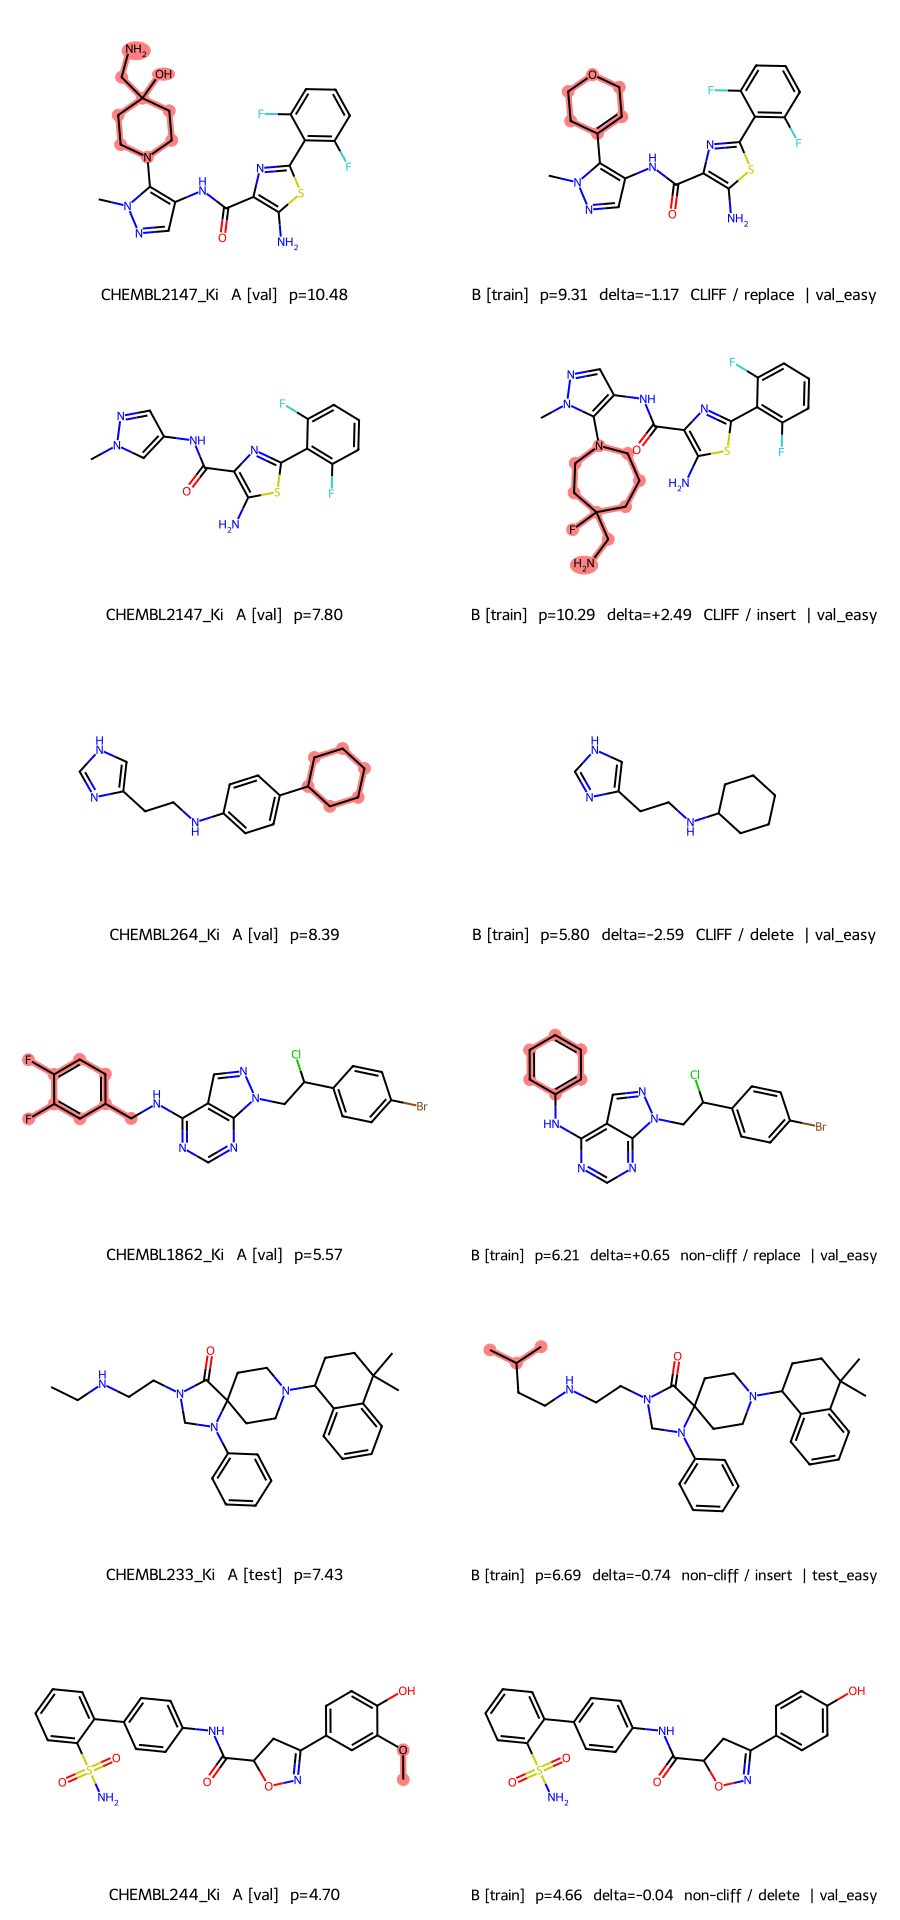

In [11]:
from rdkit.Chem import Draw, rdDepictor

def draw_pairs(rows):
    mols, highlights, legends = [], [], []
    for r in rows.itertuples():
        a, b = Chem.MolFromSmiles(r.smiles_a), Chem.MolFromSmiles(r.smiles_b)
        rdDepictor.Compute2DCoords(a)
        mcs = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                             bondCompare=rdFMCS.BondCompare.CompareOrder, ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
        rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=Chem.MolFromSmarts(mcs.smartsString), acceptFailure=True)
        mols += [a, b]
        highlights += [r.atoms_a, r.atoms_b]
        legends += [f'{r.target}  A [{r.split_a}]  p={r.p_a:.2f}',
                    f'B [{r.split_b}]  p={r.p_b:.2f}  delta={r.delta:+.2f}  {"CLIFF" if r.is_cliff else "non-cliff"} / {r.edit}  | {r.split}']
    return Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(450, 320), highlightAtomLists=highlights, legends=legends)

sample = pairs.groupby(['is_cliff', 'edit']).sample(1, random_state=SEED).sort_values(['is_cliff', 'edit'], ascending=False)
draw_pairs(sample)

## 7. easy / hard 기준

난이도는 **두 분자를 학습 때 봤는지**로 정한다. easy는 한 분자를 봤고, hard는 둘 다 처음이다.

**그림 읽는 법**: 두 줄 모두 오른쪽이 같은 평가용 분자다. 왼쪽 짝만 다르다.
짝이 학습 분자면 easy, 짝도 평가 분자면 hard.
**같은 분자라도 짝에 따라 난이도가 갈린다는 것이 요점이다.**

기준 분자 C = CHEMBL239_EC50:184


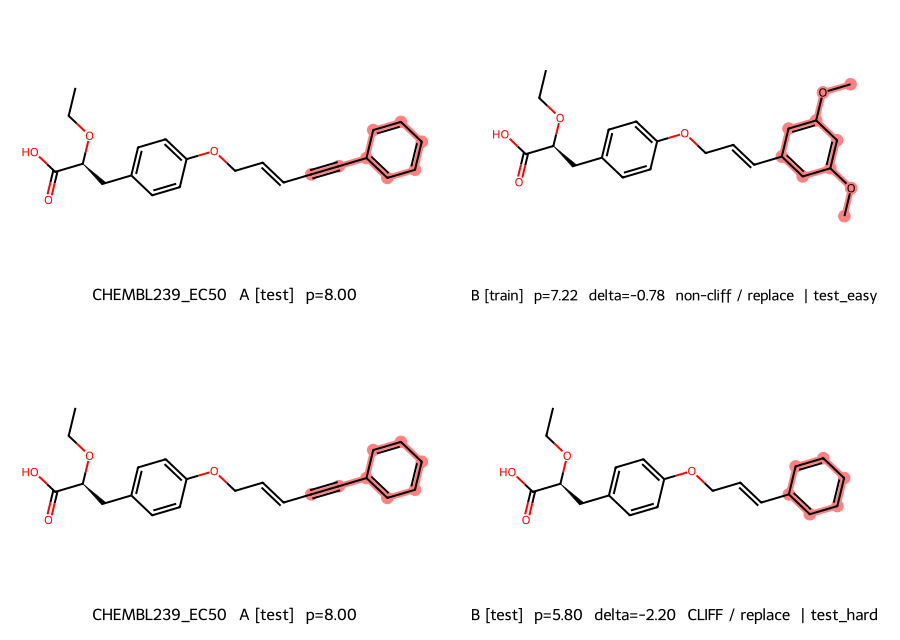

In [12]:
# 쌍마다 test 분자를 기준 분자(center)로 펼친 뒤, easy 쌍과 hard 쌍을 둘 다 가진 test 분자 하나 선택
long = pd.concat([pairs[pairs[s] == 'test'].assign(center=lambda x: x.target + ':' + x[m].astype(str))
                  for m, s in [('i', 'split_a'), ('j', 'split_b')]])
has_both = long.groupby('center').split.agg(lambda s: {'test_easy', 'test_hard'} <= set(s))
center = has_both[has_both].sample(1, random_state=SEED).index[0]
print('기준 분자 C =', center)
draw_pairs(long[long.center == center].groupby('split').sample(1, random_state=SEED).sort_values('split'))

In [13]:
# 분자 split 조합 → 쌍 split 대응 확인 (val–test 조합은 없어야 함)
pd.crosstab([pairs.split_a, pairs.split_b], pairs.split)

split            test_easy  test_hard  train  val_easy  val_hard
split_a split_b                                                 
test    test             0       6317      0         0         0
        train        20768          0      0         0         0
train   test         21487          0      0         0         0
        train            0          0  67509         0         0
        val              0          0      0     16644         0
val     train            0          0      0     17099         0
        val              0          0      0         0      4145

## 8. Baseline: 분자 단위 예측 후 차이

기존 방식의 대표로, 이 벤치마크에서 가장 성능이 좋았던 조합(지문 + SVM)을 쓴다.
타깃마다 분자 하나씩 활성값을 예측하고, 쌍 예측은 두 예측값의 차이로 낸다.
하이퍼파라미터는 검증 분자로 고르고 학습은 학습 분자만 쓴다 — 쌍 모델과 같은 조건이다.

기준선을 두 개 더 둔다.
- **항상 0**: "구조를 바꿔도 약효는 그대로"라는 예측. 오차의 눈금을 잡는 용도
- **분자 단위 RMSE**: 원 논문 수치와 대략 비교하기 위한 것

In [14]:
from sklearn.svm import SVR

SVR_C = [1, 10, 100, 1000]

def ecfp(smiles):
    return np.array([FPGEN.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in smiles], dtype=np.float32)

def tanimoto(X, Y):
    inter = X @ Y.T
    return inter / (X.sum(1)[:, None] + Y.sum(1)[None, :] - inter)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def svr_predict(target):
    """train 분자로 학습, val로 C 선택 → 모든 분자의 예측값"""
    df = load(target)
    X = ecfp(df.smiles)
    tr, va = (df.split == 'train').values, (df.split == 'val').values
    K = tanimoto(X, X[tr])
    fit = lambda C: SVR(kernel='precomputed', C=C).fit(K[tr], df.p[tr])
    val_rmse = {C: rmse(fit(C).predict(K[va]), df.p[va]) for C in SVR_C}
    best = min(val_rmse, key=val_rmse.get)
    return df.assign(pred=fit(best).predict(K)), best

mol_pred, rows = {}, []
for t in DEV_TARGETS:
    d, C = svr_predict(t)
    mol_pred[t] = d.pred
    te = d[d.split == 'test']
    rows.append(dict(target=t, C=C, test_rmse=rmse(te.pred, te.p), test_rmse_cliff_mol=rmse(te.pred[te.cliff_mol == 1], te.p[te.cliff_mol == 1])))
pairs['pred_svr'] = [mol_pred[t][j] - mol_pred[t][i] for t, i, j in zip(pairs.target, pairs.i, pairs.j)]
pairs['pred_zero'] = 0.0
pd.DataFrame(rows).round(3)

,target,C,test_rmse,test_rmse_cliff_mol
0,CHEMBL1862_Ki,10,0.756,0.655
1,CHEMBL1871_Ki,1,0.724,1.005
2,CHEMBL2034_Ki,10,0.682,0.800
3,CHEMBL2047_EC50,10,0.609,0.701
4,CHEMBL204_Ki,10,0.701,0.832
5,CHEMBL2147_Ki,100,0.589,0.610
6,CHEMBL214_Ki,10,0.665,0.774
7,CHEMBL218_EC50,10,0.758,0.802
8,CHEMBL219_Ki,1000,0.713,0.762
9,CHEMBL228_Ki,1,0.713,0.764


### 평가 표 (이후 모든 모델 공통)

쌍 난이도 × cliff 여부로 쪼갠 RMSE다.

- 모델 비교는 **평가용 easy / hard**로 한다
- 검증용은 하이퍼파라미터 선택에만 쓴다
- 학습 줄은 과적합 확인용이다

In [15]:
SPLITS = ['train', 'val_easy', 'val_hard', 'test_easy', 'test_hard']

def rmse_table(df, col, index='split'):
    se = df.assign(se=(df[col] - df.delta) ** 2)
    t = se.pivot_table(index=index, columns='is_cliff', values='se', aggfunc='mean').rename(columns={False: 'non-cliff', True: 'cliff'})
    t['all'] = se.groupby(index).se.mean()
    return t[['cliff', 'non-cliff', 'all']] ** 0.5

pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff   cliff non-cliff    all  cliff non-cliff    all
split                                                    
train      1.744     0.462  0.916  0.423     0.167  0.248
val_easy   1.752     0.464  0.917  0.946     0.446  0.593
val_hard   1.813     0.465  0.950  1.321     0.519  0.774
test_easy  1.720     0.465  0.910  0.928     0.447  0.590
test_hard  1.715     0.470  0.880  1.256     0.524  0.734

In [16]:
# 타깃별 test (특정 타깃만 망가지는지 확인)
test = pairs[pairs.split.str.startswith('test')]
pd.concat({m: rmse_table(test, f'pred_{m}', ['target', 'split']) for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff                   cliff non-cliff    all  cliff non-cliff    all
target          split                                                    
CHEMBL1862_Ki   test_easy  1.805     0.535  1.247  0.800     0.529  0.659
                test_hard  1.864     0.574  1.277  1.168     0.659  0.905
CHEMBL1871_Ki   test_easy  1.451     0.502  0.822  1.156     0.459  0.684
                test_hard  1.429     0.527  0.832  1.226     0.461  0.718
CHEMBL2034_Ki   test_easy  1.670     0.483  0.890  1.086     0.442  0.640
                test_hard  1.735     0.491  0.912  1.390     0.570  0.817
CHEMBL2047_EC50 test_easy  1.657     0.440  0.784  0.810     0.399  0.491
                test_hard  1.555     0.420  0.648  1.210     0.444  0.579
CHEMBL204_Ki    test_easy  2.018     0.464  1.178  1.068     0.469  0.707
                test_hard  2.168     0.471  1.316  1.545     0.522  0.993
CHEMBL2147_Ki   test_easy  1.933     0.525  1.181  0.661     0.460  0.533
                test_hard  1.721     0.497  1.045  0.956     0.532  0.692
CHEMBL214_Ki    test_easy  1.587     0.472  0.799  0.915     0.470  0.577
                test_hard  1.561     0.510  0.765  1.306     0.584  0.738
CHEMBL218_EC50  test_easy  1.587     0.491  0.973  0.733     0.555  0.616
                test_hard  1.524     0.496  0.858  0.879     0.572  0.658
CHEMBL219_Ki    test_easy  1.673     0.484  0.896  0.916     0.489  0.610
                test_hard  1.623     0.485  0.792  1.146     0.546  0.681
CHEMBL228_Ki    test_easy  1.707     0.484  0.886  1.318     0.438  0.714
                test_hard  1.532     0.529  0.889  1.263     0.467  0.747
CHEMBL231_Ki    test_easy  1.708     0.497  0.988  0.971     0.435  0.629
                test_hard  1.771     0.509  1.020  1.403     0.467  0.833
CHEMBL233_Ki    test_easy  1.680     0.471  0.929  1.032     0.543  0.696
                test_hard  1.738     0.480  0.953  1.488     0.631  0.916
CHEMBL234_Ki    test_easy  1.519     0.453  0.707  0.811     0.362  0.453
                test_hard  1.555     0.462  0.680  1.059     0.433  0.541
CHEMBL235_EC50  test_easy  1.853     0.498  0.966  1.414     0.456  0.770
                test_hard  1.558     0.467  0.748  1.287     0.486  0.675
CHEMBL236_Ki    test_easy  1.612     0.463  0.874  0.854     0.459  0.575
                test_hard  1.763     0.445  0.909  1.287     0.541  0.766
CHEMBL237_EC50  test_easy  1.996     0.518  1.349  0.989     0.637  0.803
                test_hard  2.014     0.524  1.139  1.519     0.677  0.979
CHEMBL237_Ki    test_easy  1.702     0.527  0.998  0.858     0.503  0.621
                test_hard  1.563     0.501  0.891  1.182     0.629  0.802
CHEMBL238_Ki    test_easy  1.589     0.451  0.848  0.852     0.438  0.557
                test_hard  1.648     0.475  0.763  1.259     0.472  0.646
CHEMBL239_EC50  test_easy  1.623     0.479  0.903  0.912     0.445  0.593
                test_hard  1.602     0.504  0.866  1.252     0.534  0.748
CHEMBL244_Ki    test_easy  1.777     0.480  0.994  0.916     0.512  0.642
                test_hard  1.737     0.519  0.963  1.183     0.598  0.779
CHEMBL262_Ki    test_easy  1.740     0.494  0.910  0.705     0.480  0.535
                test_hard  1.866     0.547  1.105  1.248     0.555  0.818
CHEMBL264_Ki    test_easy  1.570     0.472  0.822  0.786     0.475  0.552
                test_hard  1.570     0.447  0.822  1.045     0.546  0.682
CHEMBL2835_Ki   test_easy  1.429     0.291  0.355  0.775     0.224  0.248
                test_hard  1.212     0.291  0.327  1.173     0.293  0.327
CHEMBL287_Ki    test_easy  1.705     0.491  1.010  1.013     0.550  0.717
                test_hard  1.867     0.479  1.091  1.721     0.647  1.082
CHEMBL2971_Ki   test_easy  1.797     0.330  0.505  0.720     0.253  0.292
                test_hard  1.777     0.334  0.505  1.002     0.284  0.353
CHEMBL3979_EC50 test_easy  1.410     0.493  0.746  0.911     0.429  0.547
                test_hard  1.382

## 9. 그래프 입력

분자를 원자 = 노드, 결합 = 엣지 그래프로 바꾼다. 3D CNN이 준비되면 이 자리를 복셀 입력으로 바꾼다.

- **원자 특징**: 원소, 결합 수, 형식전하, 수소 수, 혼성, 방향족·고리 여부
- **결합 특징**: 결합 종류, 공액 여부
- **바뀐 원자 표시**: 조각 인코더가 이 원자들만 모은다

학습할 때만 역방향 쌍을 추가한다. 방향이 뒤집히므로 insert와 delete도 맞바꾼다.
편집 종류는 구조만으로 정해지므로 평가 때도 입력으로 쓸 수 있다.

In [17]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from rdkit.Chem.rdchem import HybridizationType as H, BondType as B

ELEMENTS = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'B', 'Si', 'Se']
HYBRID = [H.SP, H.SP2, H.SP3, H.SP3D, H.SP3D2]
BONDS = [B.SINGLE, B.DOUBLE, B.TRIPLE, B.AROMATIC]
EDITS = ['replace', 'insert', 'delete', 'multi']  # multi = 단일 부위가 아닌 학습 전용 쌍 (조각 없음)
FLIP = {'replace': 'replace', 'insert': 'delete', 'delete': 'insert', 'multi': 'multi'}

def onehot(x, choices):
    return [float(x == c) for c in choices] + [float(x not in choices)]

def atom_features(a):
    return (onehot(a.GetSymbol(), ELEMENTS) + onehot(a.GetDegree(), [0, 1, 2, 3, 4, 5]) + onehot(a.GetFormalCharge(), [-1, 0, 1])
            + onehot(a.GetTotalNumHs(), [0, 1, 2, 3]) + onehot(a.GetHybridization(), HYBRID) + [float(a.GetIsAromatic()), float(a.IsInRing())])

def graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    src, dst, edge = [], [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        f = onehot(b.GetBondType(), BONDS) + [float(b.GetIsConjugated())]
        src += [i, j]; dst += [j, i]; edge += [f, f]
    return Data(x=torch.tensor([atom_features(a) for a in mol.GetAtoms()]),
                edge_index=torch.tensor([src, dst], dtype=torch.long).reshape(2, -1),
                edge_attr=torch.tensor(edge).reshape(-1, len(BONDS) + 2))

graphs = {(t, k): graph(s) for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
N_ATOM, N_BOND = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0))), len(BONDS) + 2

def with_mask(g, atoms):
    mask = torch.zeros(g.num_nodes, dtype=torch.bool)
    mask[torch.tensor(atoms, dtype=torch.long)] = True  # atoms가 비면(multi 쌍) 전부 False → f = 0 벡터
    return Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, mask=mask)

def samples(df, both_directions=False, reverse=False):
    """reverse=True면 (B, A, −Δ)만 만든다. 양방향 평균 예측에 쓴다"""
    out = []
    for r in df.itertuples():
        ga, gb = with_mask(graphs[r.target, r.i], r.atoms_a), with_mask(graphs[r.target, r.j], r.atoms_b)
        t = DEV_TARGETS.index(r.target)
        fwd = (ga, gb, EDITS.index(r.edit), t, r.delta)
        rev = (gb, ga, EDITS.index(FLIP[r.edit]), t, -r.delta)
        out += [fwd, rev] if both_directions else [rev] if reverse else [fwd]
    return out

def collate(batch):
    ga, gb, edit, tgt, y = zip(*batch)
    return (Batch.from_data_list(ga), Batch.from_data_list(gb),
            torch.tensor(edit), torch.tensor(tgt), torch.tensor(y, dtype=torch.float32))

ga, gb, edit, tgt, y = collate(samples(pairs.head(2)))
print('원자 특징', N_ATOM, '| 결합 특징', N_BOND, '| 타깃', len(DEV_TARGETS),
      '| 배치 A 노드', ga.num_nodes, '| mask 원자', int(ga.mask.sum()), '| edit', edit.tolist())

/home/bising0922/micromamba/envs/aienv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


원자 특징 37 | 결합 특징 6 | 타깃 30 | 배치 A 노드 54 | mask 원자 12 | edit [0, 2]


## 10. 쌍 모델 + 학습

| 부분 | 구현 | 대응 |
|---|---|---|
| 분자 인코더 | GINE 3층, 두 분자가 가중치 공유 → 원자 벡터 평균 | 나중에 3D CNN이 들어갈 자리 |
| 조각 인코더 | 별도 가중치, **바뀐 원자만** 평균. 없으면 0 벡터 | ① 바뀐 부분 표현 |
| 헤드 | 두 분자 벡터 + 그 차이 + 두 조각 벡터 + 편집 종류 + 타깃 → Δ̂ | 예측 |

인코더가 원자별 벡터를 반환하는 것은 나중에 ③ 설명에서 원자 단위 기여도로 쓰기 위해서다.

**손실**은 `w = 1 + α·|Δ|`로 가중한 MSE를, 배치마다 가중치 합으로 정규화한 것이다.
차이가 큰 쌍을 더 크게 보겠다는 뜻이고, α = 0이면 평범한 MSE다.

**조기 종료는 검증 전체 RMSE로 한다.** cliff만 보면 non-cliff가 나빠지는 것을 막지 못한다.
cliff를 중시하는 역할은 손실의 α가 이미 맡고 있으므로, 모델 선택은 중립적으로 둔다.

가중치는 설정값을 파일 이름에 넣어 저장한다. 설정을 바꾸면 캐시가 자동으로 갈려 옛 가중치를 재사용하는 사고가 없다.
진행 상황은 따로 로그에 남긴다 — 노트북 출력은 실행이 끝나야 저장되기 때문이다.

In [18]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 공용 GPU다. 쌍 생성·그래프 변환에 수 분이 걸리는 사이 다른 사용자가 GPU를 통째로 채우면
# 학습 시작 시점에 OOM이 난다. 실제로 겪었으므로 미리 4GB를 잡아 캐싱 할당자에 남긴다
if torch.cuda.is_available():
    _reserve = torch.empty(int(4e9 // 4), dtype=torch.float32, device='cuda'); del _reserve
HIDDEN, LAYERS, BATCH, LR, EPOCHS = 64, 3, 256, 1e-3, 200
DROPOUT, WD = 0.3, 1e-4   # 과적합 대응: 폭 128→64, dropout 0.1→0.3, weight decay
# 30개 타깃이면 epoch당 본 쌍이 12.7배라 훨씬 적은 epoch에 수렴한다 → patience를 줄인다
PATIENCE = 8 if USE_ALL_TARGETS else 20
ALPHAS = [0, 0.5, 1, 2, 4]  # α를 하나로 고르지 않고 cliff↔non-cliff 교환 곡선을 그린다.
                            # {0, 2} × 시드 3개는 이미 캐시돼 있어 9회만 새로 학습한다
RUNS = 'runs'
# 설정이 바뀌면 캐시 파일 이름이 달라진다 → 예전 가중치를 조용히 재사용하는 사고를 막는다
TAG = f't{len(DEV_TARGETS)}_h{HIDDEN}_dr{DROPOUT}_wd{WD}_exp{int(EXPAND_TRAIN)}'
os.makedirs(RUNS, exist_ok=True)

def log(*msg):
    print(*msg)
    with open(f'{RUNS}/train.log', 'a') as f:
        print(pd.Timestamp.now().strftime('%m-%d %H:%M:%S'), *msg, file=f)

class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Linear(N_ATOM, HIDDEN)
        self.convs = nn.ModuleList(GINEConv(nn.Sequential(nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, HIDDEN)), edge_dim=N_BOND)
                                   for _ in range(LAYERS))

    def forward(self, g):
        h = self.inp(g.x)
        for conv in self.convs:
            h = h + F.relu(conv(h, g.edge_index, g.edge_attr))
        return h  # 원자별 벡터

def masked_mean(h, g):
    m = g.mask.float().unsqueeze(1)
    return global_add_pool(h * m, g.batch, g.num_graphs) / global_add_pool(m, g.batch, g.num_graphs).clamp(min=1)

class PairModel(nn.Module):
    """타깃 one-hot을 입력에 넣는다. 30개 타깃에서는 고유 분자 35,633개 중 9,507개(26.7%)가
    2개 이상 타깃에 등장하므로, 타깃 정보가 없으면 같은 쌍이 서로 다른 Δ를 갖는 것을 구분할 수 없다"""
    def __init__(self):
        super().__init__()
        self.mol, self.frag = GNN(), GNN()
        n_in = 5 * HIDDEN + len(EDITS) + len(DEV_TARGETS)
        self.head = nn.Sequential(nn.Linear(n_in, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def forward(self, ga, gb, edit, tgt):
        ha, hb = global_mean_pool(self.mol(ga), ga.batch), global_mean_pool(self.mol(gb), gb.batch)
        fa, fb = masked_mean(self.frag(ga), ga), masked_mean(self.frag(gb), gb)
        x = torch.cat([ha, hb, hb - ha, fa, fb,
                       F.one_hot(edit, len(EDITS)).float(),
                       F.one_hot(tgt, len(DEV_TARGETS)).float()], 1)
        return self.head(x).squeeze(1)

def forward_pred(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE)).cpu()
                          for ga, gb, e, t, _ in loader]).numpy()

def loaders(df):
    """(정방향, 역방향) loader 한 쌍"""
    return (DataLoader(samples(df), 1024, collate_fn=collate),
            DataLoader(samples(df, reverse=True), 1024, collate_fn=collate))

def predict(model, lds):
    """양방향 평균 Δ̂ = (Δ̂(A,B) − Δ̂(B,A)) / 2.
    모델은 반대칭 Δ̂(B,A) = −Δ̂(A,B) 를 정확히 지키지 않으므로, 평균이 그 어긋남만큼 오차를 깎는다"""
    return (forward_pred(model, lds[0]) - forward_pred(model, lds[1])) / 2

# num_workers=8: 실측으로 배치당 68.7ms → 55.1ms (약 20%). 16은 오히려 느려진다(과다구독).
# 나머지 시간은 작은 텐서에 대한 커널 실행 오버헤드라 워커로는 더 줄지 않는다
train_loader = DataLoader(samples(train_pairs, both_directions=True), BATCH, shuffle=True,
                          collate_fn=collate, num_workers=8, persistent_workers=True, pin_memory=True)
val = pairs[pairs.split.str.startswith('val')]
val_lds, all_lds = loaders(val), loaders(pairs)
val_is_cliff = val.is_cliff.values

# 학습 곡선용: train 쌍 중 단일 부위 쌍만 val과 같은 규모로 고정 추출한다.
# val과 분포·개수를 맞춰야 두 곡선의 격차를 과적합으로 읽을 수 있다
train_eval = pairs[pairs.split == 'train'].sample(len(val), random_state=SEED)
train_eval_lds = loaders(train_eval)
train_eval_is_cliff = train_eval.is_cliff.values

def scores(df_delta, is_cliff, lds, model):
    p = predict(model, lds)
    return rmse(p, df_delta), rmse(p[is_cliff], df_delta[is_cliff])

def val_scores(model):
    """(val 전체 RMSE, val cliff RMSE). 앞쪽이 조기 종료 기준"""
    return scores(val.delta, val_is_cliff, val_lds, model)

def train_scores(model):
    return scores(train_eval.delta, train_eval_is_cliff, train_eval_lds, model)

def train(alpha, seed):
    path = f'{RUNS}/gnn_a{alpha}_{TAG}_seed{seed}.pt'
    hist_path = f'{RUNS}/hist_a{alpha}_{TAG}_seed{seed}.csv'
    torch.manual_seed(seed)
    model = PairModel().to(DEVICE)
    # 가중치와 학습 이력이 둘 다 있을 때만 캐시를 쓴다 (이력 없는 옛 체크포인트는 다시 학습)
    if os.path.exists(path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(path))
        v, vc = val_scores(model)
        log(f'a={alpha} s={seed} 저장된 가중치 사용 | val_rmse={v:.3f} val_cliff={vc:.3f}')
        return model
    hist = []
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    best, best_state, wait = float('inf'), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for ga, gb, e, t, y in train_loader:
            ga, gb, e, t, y = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE), y.to(DEVICE)
            w = 1 + alpha * y.abs()
            loss = (w * (model(ga, gb, e, t) - y) ** 2).sum() / w.sum()
            opt.zero_grad(); loss.backward(); opt.step()
        score, cliff = val_scores(model)
        tr, tr_cliff = train_scores(model)
        hist.append(dict(epoch=epoch, train=tr, train_cliff=tr_cliff, val=score, val_cliff=cliff))
        if score < best:
            best, wait = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 5 == 0 or wait >= PATIENCE:
            log(f'a={alpha} s={seed} epoch={epoch} loss={loss.item():.3f} val_rmse={score:.3f} val_cliff={cliff:.3f} best={best:.3f}')
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    # 끝까지 학습한 경우에만 저장 → 중간에 끊겨도 캐시가 오염되지 않는다
    pd.DataFrame(hist).assign(best_epoch=int(np.argmin([h['val'] for h in hist]))).to_csv(hist_path, index=False)
    torch.save(best_state, path)
    return model

log(f'device={DEVICE} tag={TAG} targets={len(DEV_TARGETS)} train_samples={len(train_loader.dataset)} '
    f'val={len(val)} alphas={ALPHAS} seeds={SEEDS}')
for a in ALPHAS:
    for s in SEEDS:
        m = train(a, s)
        pairs[f'pred_gnn_a{a}_s{s}'] = predict(m, all_lds)            # 양방향 평균
        if s == SEEDS[0]:
            pairs[f'pred_gnn_a{a}_fwd'] = forward_pred(m, all_lds[0])  # 비교용 단방향 (대표 시드)

device=cuda tag=t30_h64_dr0.3_wd0.0001_exp1 targets=30 train_samples=699130 val=37888 alphas=[0, 0.5, 1, 2, 4] seeds=[0, 1, 2]


a=0 s=0 저장된 가중치 사용 | val_rmse=0.705 val_cliff=1.158


a=0 s=1 저장된 가중치 사용 | val_rmse=0.718 val_cliff=1.175


a=0 s=2 저장된 가중치 사용 | val_rmse=0.711 val_cliff=1.156


a=0.5 s=0 epoch=0 loss=1.238 val_rmse=0.864 val_cliff=1.533 best=0.864


...

a=4 s=2 epoch=15 loss=0.455 val_rmse=0.794 val_cliff=1.180 best=0.781


a=4 s=2 epoch=20 loss=0.612 val_rmse=0.788 val_cliff=1.170 best=0.763


a=4 s=2 epoch=25 loss=0.486 val_rmse=0.774 val_cliff=1.167 best=0.763


a=4 s=2 epoch=30 loss=0.510 val_rmse=0.769 val_cliff=1.140 best=0.750


a=4 s=2 epoch=34 loss=0.465 val_rmse=0.768 val_cliff=1.128 best=0.750


In [19]:
# 학습 기록 (runs/train.log). 가중치가 캐시된 경우 이 셀이 실제 학습 과정을 보여준다
print(open(f'{RUNS}/train.log').read()[-3000:])

5
09-22 23:55:53 a=1 s=2 epoch=0 loss=1.120 val_rmse=0.876 val_cliff=1.537 best=0.876
09-23 00:09:18 a=1 s=2 epoch=5 loss=0.763 val_rmse=0.787 val_cliff=1.289 best=0.787
09-23 00:22:52 a=1 s=2 epoch=10 loss=0.721 val_rmse=0.772 val_cliff=1.206 best=0.770
09-23 00:36:27 a=1 s=2 epoch=15 loss=0.431 val_rmse=0.765 val_cliff=1.183 best=0.758
09-23 00:49:55 a=1 s=2 epoch=20 loss=0.452 val_rmse=0.751 val_cliff=1.128 best=0.751
09-23 01:03:26 a=1 s=2 epoch=25 loss=0.378 val_rmse=0.733 val_cliff=1.117 best=0.733
09-23 01:16:58 a=1 s=2 epoch=30 loss=0.440 val_rmse=0.729 val_cliff=1.127 best=0.729
09-23 01:30:28 a=1 s=2 epoch=35 loss=0.447 val_rmse=0.727 val_cliff=1.112 best=0.721
09-23 01:44:08 a=1 s=2 epoch=40 loss=0.298 val_rmse=0.723 val_cliff=1.092 best=0.721
09-23 01:57:41 a=1 s=2 epoch=45 loss=0.393 val_rmse=0.735 val_cliff=1.093 best=0.716
09-23 02:11:06 a=1 s=2 epoch=50 loss=0.331 val_rmse=0.739 val_cliff=1.096 best=0.716
09-23 02:11:26 a=2 s=0 저장된 가중치 사용 | val_rmse=0.736 val_cliff=1.11

## 11. α 선택 + baseline 비교

- **α 선택**: 검증 cliff RMSE가 가장 낮은 값. non-cliff가 얼마나 손해 보는지 옆에 같이 본다
- **최종 비교**는 평가 split에서 한다 — 기준선 둘(항상 0 / baseline)과 쌍 모델 둘(가중 없음 / 선택된 α)
- 이어서 시드 편차, 학습 곡선, α 교환 곡선, 구간별 오차, 과분산 진단을 본다

In [20]:
val = pairs[pairs.split.str.startswith('val')]

def seed_rmse(df, a, mask=None):
    """시드 3개의 RMSE를 배열로 반환"""
    d = df if mask is None else df[mask]
    return np.array([rmse(d[f'pred_gnn_a{a}_s{s}'], d.delta) for s in SEEDS])

# 열 이름과 맞추려고 문자열 키를 쓴다 (0과 0.5가 섞이면 pandas가 인덱스를 float으로 바꾼다)
alpha_table = pd.DataFrame({str(a): {
    'val cliff': seed_rmse(val, a, val.is_cliff).mean(),
    'val cliff 폭': np.ptp(seed_rmse(val, a, val.is_cliff)),
    'val non-cliff': seed_rmse(val, a, ~val.is_cliff).mean(),
    'val all': seed_rmse(val, a).mean()} for a in ALPHAS}).T.rename_axis('alpha')
BEST_ALPHA = alpha_table['val cliff'].idxmin()

# 그림·산점도용 대표 시드 (표는 시드 3개를 모두 쓴다)
for a in ALPHAS:
    pairs[f'pred_gnn_a{a}'] = pairs[f'pred_gnn_a{a}_s{SEEDS[0]}']
for s in SEEDS:
    pairs[f'pred_gnn_best_s{s}'] = pairs[f'pred_gnn_a{BEST_ALPHA}_s{s}']
pairs['pred_gnn_best'] = pairs[f'pred_gnn_best_s{SEEDS[0]}']
pairs['pred_gnn_best_fwd'] = pairs[f'pred_gnn_a{BEST_ALPHA}_fwd']
log(f'best alpha = {BEST_ALPHA} (시드 {SEEDS} 평균 val cliff RMSE 기준)')
alpha_table.round(3)

best alpha = 1 (시드 [0, 1, 2] 평균 val cliff RMSE 기준)


,val cliff,val cliff 폭,val non-cliff,val all
alpha,,,,
0,1.163,0.018,0.518,0.712
0.5,1.142,0.058,0.546,0.721
1,1.135,0.065,0.559,0.726
2,1.136,0.045,0.582,0.741
4,1.155,0.008,0.596,0.755


### 시드 편차 표 — 이번 실행의 핵심

모델 간 격차를 **실행 간 편차와 나란히** 놓는다.
시드를 바꿨을 때의 폭이 모델 간 차이보다 크면, 그 비교는 시드 하나로 말할 수 없다.

In [21]:
rows = []
for a in ALPHAS:
    for sp in ['test_easy', 'test_hard']:
        d = pairs[pairs.split == sp]
        for lbl, m in [('cliff', d.is_cliff), ('non-cliff', ~d.is_cliff)]:
            v, dm = seed_rmse(d, a, m), d[m]
            rows.append({'alpha': a, 'split': sp, 'kind': lbl, 'GNN 평균': v.mean(),
                         'GNN 최소': v.min(), 'GNN 최대': v.max(), '폭': np.ptp(v),
                         'SVR': rmse(dm.pred_svr, dm.delta), 'zero': rmse(dm.pred_zero, dm.delta)})
seed_table = pd.DataFrame(rows).set_index(['alpha', 'split', 'kind'])
seed_table['GNN−SVR'] = seed_table['GNN 평균'] - seed_table.SVR
seed_table.round(3)

GNN 평균  GNN 최소  GNN 최대      폭    SVR   zero  \
alpha split     kind                                                     
0.0   test_easy cliff       1.120   1.104   1.137  0.032  0.928  1.720   
                non-cliff   0.507   0.505   0.512  0.007  0.447  0.465   
      test_hard cliff       1.339   1.324   1.358  0.034  1.256  1.715   
                non-cliff   0.576   0.572   0.578  0.006  0.524  0.470   
0.5   test_easy cliff       1.090   1.060   1.109  0.049  0.928  1.720   
                non-cliff   0.532   0.525   0.538  0.013  0.447  0.465   
      test_hard cliff       1.311   1.300   1.329  0.029  1.256  1.715   
                non-cliff   0.605   0.590   0.621  0.031  0.524  0.470   
1.0   test_easy cliff       1.079   1.041   1.113  0.073  0.928  1.720   
                non-cliff   0.549   0.545   0.558  0.013  0.447  0.465   
      test_hard cliff       1.282   1.276   1.286  0.010  1.256  1.715   
                non-cliff   0.618   0.611   0.631  0.021  0.524  0.470   
2.0   test_easy cliff       1.064   1.023   1.088  0.065  0.928  1.720   
                non-cliff   0.562   0.559   0.568  0.009  0.447  0.465   
      test_hard cliff       1.275   1.239   1.311  0.071  1.256  1.715   
                non-cliff   0.641   0.637   0.647  0.010  0.524  0.470   
4.0   test_easy cliff       1.086   1.068   1.101  0.034  0.928  1.720   
                non-cliff   0.583   0.577   0.595  0.018  0.447  0.465   
      test_hard cliff       1.305   1.299   1.314  0.015  1.256  1.715   
                non-cliff   0.650   0.638   0.665  0.027  0.524  0.470   

                           GNN−SVR  
alpha split     kind                
0.0   test_easy cliff        0.193  
                non-cliff    0.060  
      test_hard cliff        0.083  
                non-cliff    0.052  
0.5   test_easy cliff        0.162  
                non-cliff    0.084  
      test_hard cliff        0.055  
                non-cliff    0.081  
1.0   test_easy cliff        0.151  
                non-cliff    0.102  
      test_hard cliff        0.026  
                non-cliff    0.094  
2.0   test_easy cliff        0.136  
                non-cliff    0.115  
      test_hard cliff        0.019  
                non-cliff    0.118  
4.0   test_easy cliff        0.158  
                non-cliff    0.136  
      test_hard cliff        0.049  
                non-cliff    0.126

### 학습 곡선

학습 곡선은 **검증 세트와 같은 규모로 고정 추출한 학습 쌍**에서 잰 값이다.
분포와 개수를 맞춰야 두 선의 격차를 그대로 과적합으로 읽을 수 있다.

- **왼쪽**: 선택된 설정의 학습 / 검증 RMSE. 두 선이 벌어지는 지점이 과적합이 시작되는 곳이고, ▼가 조기 종료가 고른 지점
- **가운데**: 같은 것을 cliff 쌍만으로
- **오른쪽**: α와 시드를 모두 겹쳐 그린 것. 선끼리 얼마나 떨어져 있는지가 곧 비교 가능성이다

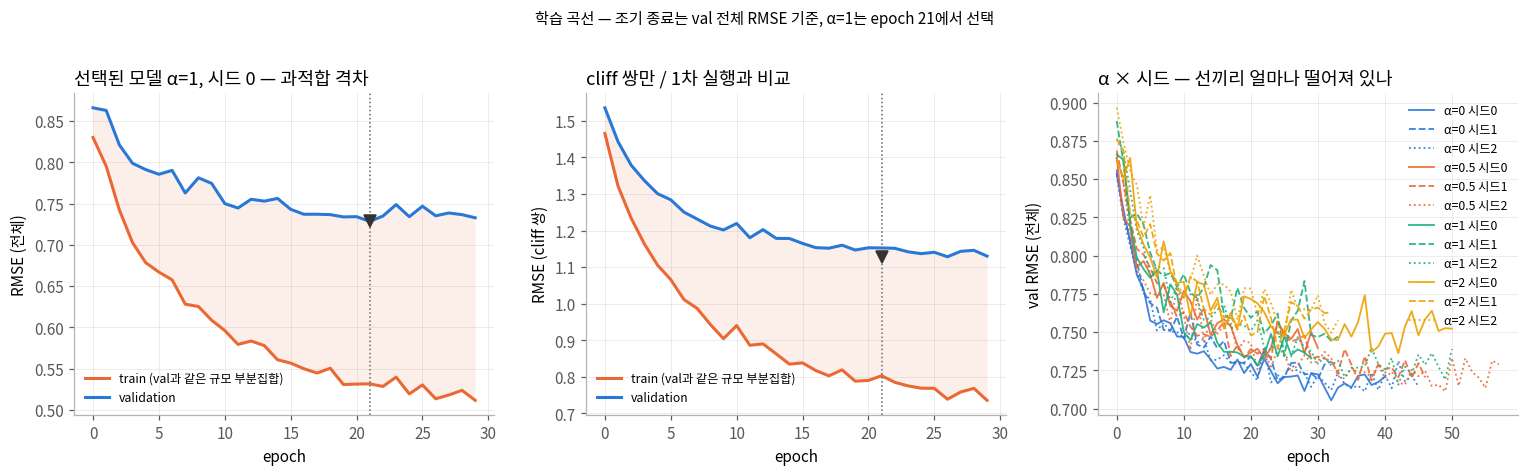

,train,val,train cliff,val cliff,best epoch,격차(val/train)
α=0 시드0,0.515,0.705,0.840,1.158,32.0,1.371
α=0 시드1,0.528,0.718,0.865,1.175,24.0,1.361
α=0 시드2,0.511,0.711,0.816,1.156,37.0,1.393
α=0.5 시드0,0.531,0.733,0.831,1.173,22.0,1.380
α=0.5 시드1,0.511,0.718,0.792,1.139,38.0,1.407
α=0.5 시드2,0.490,0.711,0.746,1.115,49.0,1.451
α=1 시드0,0.532,0.728,0.803,1.153,21.0,1.370
α=1 시드1,0.547,0.735,0.827,1.158,25.0,1.344
α=1 시드2,0.484,0.716,0.698,1.093,42.0,1.479
α=2 시드0,0.497,0.736,0.687,1.113,42.0,1.482


In [22]:
import re
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Noto Sans CJK JP', 'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6, 'axes.axisbelow': True})

# 검증된 기본 categorical 팔레트의 앞 네 칸 (파랑 / 주황 / 아쿠아 / 노랑)
C1, C2, C3, C4 = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
SURFACE, MUTED = 'white', '0.45'

def tidy(a):
    a.spines[['top', 'right']].set_visible(False)
    a.spines[['left', 'bottom']].set_color('0.7')
    a.tick_params(colors='0.35', length=3)

hist = {(str(a), s): pd.read_csv(f'{RUNS}/hist_a{a}_{TAG}_seed{s}.csv') for a in ALPHAS for s in SEEDS}
h = hist[(BEST_ALPHA, SEEDS[0])]
stop = int(h.best_epoch[0])

# 4개 타깃일 때만 1차 실행(2026-09-16)과 겹쳐 그린다. 30개 타깃과는 비교 대상이 아니다
PAT = re.compile(r'09-16 \S+ alpha=4 epoch=(\d+) \S+ val_cliff_rmse=([\d.]+)')
first = [] if USE_ALL_TARGETS else [(int(m[1]), float(m[2])) for l in open(f'{RUNS}/train.log') if (m := PAT.match(l))]

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

for a_, col, lbl in [(ax[0], ['train', 'val'], 'RMSE (전체)'), (ax[1], ['train_cliff', 'val_cliff'], 'RMSE (cliff 쌍)')]:
    a_.plot(h.epoch, h[col[0]], color=C2, lw=2, label='train (val과 같은 규모 부분집합)')
    a_.plot(h.epoch, h[col[1]], color=C1, lw=2, label='validation')
    a_.fill_between(h.epoch, h[col[0]], h[col[1]], color=C2, alpha=0.10, lw=0)
    a_.axvline(stop, color='0.4', lw=1, ls=':')
    a_.plot([stop], [h[col[1]].min()], marker='v', color='0.2', ms=8, clip_on=False)
    a_.set(xlabel='epoch', ylabel=lbl)
if first:
    ax[1].plot(*zip(*first), color=MUTED, ls='--', lw=1.5, marker='.', ms=5, label='1차 실행 α=4 (val cliff)')
ax[0].set_title(f'선택된 모델 α={BEST_ALPHA}, 시드 {SEEDS[0]} — 과적합 격차', loc='left')
ax[1].set_title('cliff 쌍만 / 1차 실행과 비교', loc='left')

for a, c in zip(ALPHAS, [C1, C2, C3, C4]):
    for j, s in enumerate(SEEDS):
        d = hist[(str(a), s)]
        ax[2].plot(d.epoch, d.val, color=c, lw=1.2, ls=['-', '--', ':'][j % 3], alpha=.9,
                   label=f'α={a} 시드{s}')
ax[2].set(xlabel='epoch', ylabel='val RMSE (전체)')
ax[2].set_title('α × 시드 — 선끼리 얼마나 떨어져 있나', loc='left')

for a_ in ax:
    a_.legend(fontsize=8, frameon=False); tidy(a_)
fig.suptitle(f'학습 곡선 — 조기 종료는 val 전체 RMSE 기준, α={BEST_ALPHA}는 epoch {stop}에서 선택', y=1.02, fontsize=10)
fig.tight_layout()
plt.show()

gap = pd.DataFrame({f'α={a} 시드{s}': {'train': d.train[e], 'val': d.val[e], 'train cliff': d.train_cliff[e],
                                       'val cliff': d.val_cliff[e], 'best epoch': e}
                    for a in ALPHAS for s in SEEDS
                    for d in [hist[(str(a), s)]] for e in [int(d.best_epoch[0])]}).T
gap['격차(val/train)'] = gap.val / gap.train
gap.round(3)

### α 교환 곡선

**α에는 최적값이 없다.** cliff 정확도와 non-cliff 정확도 사이의 **교환비를 정하는 손잡이**이고,
어느 지점이 맞는지는 용도가 정한다. 그래서 값 하나를 주장하는 대신 곡선 자체를 결과로 보고한다.

- 점 하나 = α 값 하나, 오차막대 = 시드 3개의 최소~최대
- **왼쪽 아래가 좋다**
- 세로 점선 오른쪽은 **"항상 0이라고 답하느니만 못한" 영역**이다

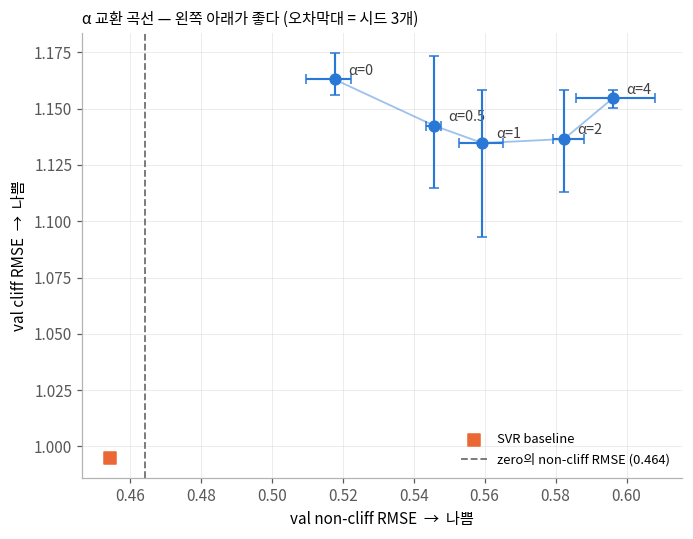

,val cliff,val non-cliff,cliff 폭,non-cliff 폭
alpha,,,,
0,1.163,0.518,0.018,0.013
0.5,1.142,0.546,0.058,0.004
1,1.135,0.559,0.065,0.012
2,1.136,0.582,0.045,0.009
4,1.155,0.596,0.008,0.022


In [23]:
fig, a_ = plt.subplots(figsize=(6.4, 5.0))
pts = []
for a in ALPHAS:
    nc, cl = seed_rmse(val, a, ~val.is_cliff), seed_rmse(val, a, val.is_cliff)
    a_.errorbar(nc.mean(), cl.mean(),
                xerr=[[nc.mean() - nc.min()], [nc.max() - nc.mean()]],
                yerr=[[cl.mean() - cl.min()], [cl.max() - cl.mean()]],
                fmt='o', ms=7, color=C1, ecolor=C1, elinewidth=1.4, capsize=3, zorder=3)
    a_.annotate(f'α={a}', (nc.mean(), cl.mean()), textcoords='offset points', xytext=(9, 3),
                fontsize=9.5, color='0.25')
    pts.append((nc.mean(), cl.mean()))
a_.plot(*zip(*sorted(pts)), color=C1, lw=1.2, alpha=.45, zorder=2)

nc_m, cl_m = ~val.is_cliff, val.is_cliff
a_.scatter([rmse(val[nc_m].pred_svr, val[nc_m].delta)], [rmse(val[cl_m].pred_svr, val[cl_m].delta)],
           marker='s', s=60, color=C2, zorder=4, label='SVR baseline')
zero_nc = rmse(val[nc_m].pred_zero, val[nc_m].delta)
a_.axvline(zero_nc, color=MUTED, ls='--', lw=1.2, zorder=1,
           label=f'zero의 non-cliff RMSE ({zero_nc:.3f})')
a_.set(xlabel='val non-cliff RMSE  →  나쁨', ylabel='val cliff RMSE  →  나쁨')
a_.set_title('α 교환 곡선 — 왼쪽 아래가 좋다 (오차막대 = 시드 3개)', loc='left', fontsize=10)
a_.legend(fontsize=8.5, frameon=False); tidy(a_)
fig.tight_layout(); plt.show()

pareto = pd.DataFrame({str(a): {'val cliff': seed_rmse(val, a, val.is_cliff).mean(),
                                'val non-cliff': seed_rmse(val, a, ~val.is_cliff).mean(),
                                'cliff 폭': np.ptp(seed_rmse(val, a, val.is_cliff)),
                                'non-cliff 폭': np.ptp(seed_rmse(val, a, ~val.is_cliff))}
                       for a in ALPHAS}).T.rename_axis('alpha')
pareto.round(3)

In [24]:
MODELS = ['zero', 'svr', 'gnn_a0', 'gnn_best']
pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in MODELS}, axis=1).round(3)

zero                     svr                  gnn_a0            \
is_cliff   cliff non-cliff    all  cliff non-cliff    all  cliff non-cliff   
split                                                                        
train      1.744     0.462  0.916  0.423     0.167  0.248  0.840     0.373   
val_easy   1.752     0.464  0.917  0.946     0.446  0.593  1.134     0.502   
val_hard   1.813     0.465  0.950  1.321     0.519  0.774  1.336     0.568   
test_easy  1.720     0.465  0.910  0.928     0.447  0.590  1.120     0.505   
test_hard  1.715     0.470  0.880  1.256     0.524  0.734  1.334     0.572   

                 gnn_best                   
is_cliff     all    cliff non-cliff    all  
split                                       
train      0.514    0.803     0.424  0.532  
val_easy   0.692    1.126     0.546  0.715  
val_hard   0.806    1.346     0.607  0.831  
test_easy  0.691    1.082     0.545  0.702  
test_hard  0.789    1.286     0.611  0.796

In [25]:
test = pairs[pairs.split.str.startswith('test')]
pd.concat({m: rmse_table(test, f'pred_{m}', ['target', 'split']) for m in MODELS}, axis=1).round(3)

zero                     svr                   \
is_cliff                   cliff non-cliff    all  cliff non-cliff    all   
target          split                                                       
CHEMBL1862_Ki   test_easy  1.805     0.535  1.247  0.800     0.529  0.659   
                test_hard  1.864     0.574  1.277  1.168     0.659  0.905   
CHEMBL1871_Ki   test_easy  1.451     0.502  0.822  1.156     0.459  0.684   
                test_hard  1.429     0.527  0.832  1.226     0.461  0.718   
CHEMBL2034_Ki   test_easy  1.670     0.483  0.890  1.086     0.442  0.640   
                test_hard  1.735     0.491  0.912  1.390     0.570  0.817   
CHEMBL2047_EC50 test_easy  1.657     0.440  0.784  0.810     0.399  0.491   
                test_hard  1.555     0.420  0.648  1.210     0.444  0.579   
CHEMBL204_Ki    test_easy  2.018     0.464  1.178  1.068     0.469  0.707   
                test_hard  2.168     0.471  1.316  1.545     0.522  0.993   
CHEMBL2147_Ki   test_easy  1.933     0.525  1.181  0.661     0.460  0.533   
                test_hard  1.721     0.497  1.045  0.956     0.532  0.692   
CHEMBL214_Ki    test_easy  1.587     0.472  0.799  0.915     0.470  0.577   
                test_hard  1.561     0.510  0.765  1.306     0.584  0.738   
CHEMBL218_EC50  test_easy  1.587     0.491  0.973  0.733     0.555  0.616   
                test_hard  1.524     0.496  0.858  0.879     0.572  0.658   
CHEMBL219_Ki    test_easy  1.673     0.484  0.896  0.916     0.489  0.610   
                test_hard  1.623     0.485  0.792  1.146     0.546  0.681   
CHEMBL228_Ki    test_easy  1.707     0.484  0.886  1.318     0.438  0.714   
                test_hard  1.532     0.529  0.889  1.263     0.467  0.747   
CHEMBL231_Ki    test_easy  1.708     0.497  0.988  0.971     0.435  0.629   
                test_hard  1.771     0.509  1.020  1.403     0.467  0.833   
CHEMBL233_Ki    test_easy  1.680     0.471  0.929  1.032     0.543  0.696   
                test_hard  1.738     0.480  0.953  1.488     0.631  0.916   
CHEMBL234_Ki    test_easy  1.519     0.453  0.707  0.811     0.362  0.453   
                test_hard  1.555     0.462  0.680  1.059     0.433  0.541   
CHEMBL235_EC50  test_easy  1.853     0.498  0.966  1.414     0.456  0.770   
                test_hard  1.558     0.467  0.748  1.287     0.486  0.675   
CHEMBL236_Ki    test_easy  1.612     0.463  0.874  0.854     0.459  0.575   
                test_hard  1.763     0.445  0.909  1.287     0.541  0.766   
CHEMBL237_EC50  test_easy  1.996     0.518  1.349  0.989     0.637  0.803   
                test_hard  2.014     0.524  1.139  1.519     0.677  0.979   
CHEMBL237_Ki    test_easy  1.702     0.527  0.998  0.858     0.503  0.621   
                test_hard  1.563     0.501  0.891  1.182     0.629  0.802   
CHEMBL238_Ki    test_easy  1.589     0.451  0.848  0.852     0.438  0.557   
                test_hard  1.648     0.475  0.763  1.259     0.472  0.646   
CHEMBL239_EC50  test_easy  1.623     0.479  0.903  0.912     0.445  0.593   
                test_hard  1.602     0.504  0.866  1.252     0.534  0.748   
CHEMBL244_Ki    test_easy  1.777     0.480  0.994  0.916     0.512  0.642   
                test_hard  1.737     0.519  0.963  1.183     0.598  0.779   
CHEMBL262_Ki    test_easy  1.740     0.494  0.910  0.705     0.480  0.535   
                test_hard  1.866     0.547  1.105  1.248     0.555  0.818   
CHEMBL264_Ki    test_easy  1.570     0.472  0.822  0.786     0.475  0.552   
                test_hard  1.570     0.447  0.822  1.045     0.546  0.682   
CHEMBL2835_Ki   test_easy  1.429     0.291  0.355  0.775     0.224  0.248   
                test_hard  1.212     0.291  0.327  1.173     0.293  0.327   
CHEMBL287_Ki    test_easy  1.705     0.491  1.010  1.013     0.550  0.717   
                test_hard  1.867     0.479  1.091  1.721     0.647  1.082   
CHEMBL2971_Ki   test_easy  1.797     0.330  0.505  0.720     0.253  0.292   
                test_har

타깃을 **학습 쌍이 많은 순서**로 놓고, 가장 어려운 칸(hard × cliff)의 오차를 비교한다.

쌍 모델이 SVR보다 나은 타깃: 11 / 30


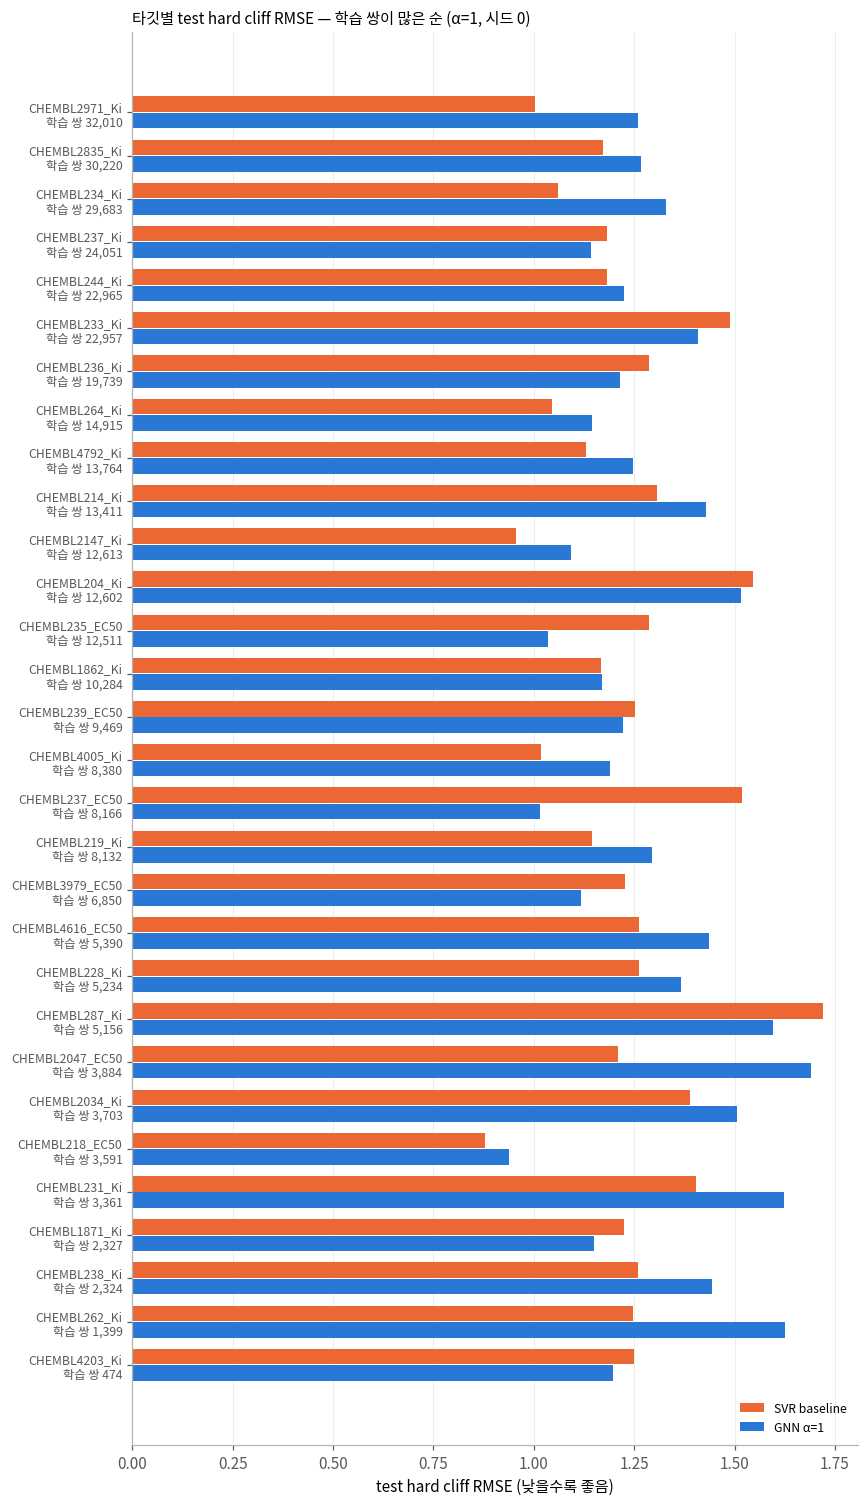

,svr,gnn_best,n_train
CHEMBL4203_Ki,1.249,1.199,474
CHEMBL262_Ki,1.248,1.626,1399
CHEMBL238_Ki,1.259,1.444,2324
CHEMBL1871_Ki,1.226,1.150,2327
CHEMBL231_Ki,1.403,1.623,3361
CHEMBL218_EC50,0.879,0.938,3591
CHEMBL2034_Ki,1.390,1.506,3703
CHEMBL2047_EC50,1.210,1.690,3884
CHEMBL287_Ki,1.721,1.597,5156
CHEMBL228_Ki,1.263,1.365,5234


In [26]:
hard = pairs[(pairs.split == 'test_hard') & pairs.is_cliff]
per = pd.DataFrame({m: {t: rmse(d[f'pred_{m}'], d.delta) for t, d in hard.groupby('target')}
                    for m in ['svr', 'gnn_best']})
per['n_train'] = train_pairs.target.value_counts()
per = per.sort_values('n_train')

fig, a_ = plt.subplots(figsize=(8, max(3.6, 0.42 * len(per) + 1.2)))
y, hgt = np.arange(len(per)), 0.36
a_.barh(y + hgt / 2 * 1.06, per.svr, hgt, color=C2, label='SVR baseline', zorder=2)
a_.barh(y - hgt / 2 * 1.06, per.gnn_best, hgt, color=C1, label=f'GNN α={BEST_ALPHA}', zorder=2)
if len(per) <= 8:   # 타깃이 많으면 주석이 더 방해가 된다
    for i, (t_, r) in enumerate(per.iterrows()):
        win = r.gnn_best < r.svr
        a_.text(max(r.svr, r.gnn_best) + 0.04, i, '쌍 모델 우세' if win else '쌍 모델 열세',
                va='center', fontsize=8, color=C1 if win else '0.45')
print(f'쌍 모델이 SVR보다 나은 타깃: {int((per.gnn_best < per.svr).sum())} / {len(per)}')
a_.set(yticks=y, xlabel='test hard cliff RMSE (낮을수록 좋음)')
a_.set_yticklabels([f'{t}\n학습 쌍 {n:,}' for t, n in zip(per.index, per.n_train)], fontsize=8)
a_.legend(fontsize=8, frameon=False, loc='lower right'); a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title(f'타깃별 test hard cliff RMSE — 학습 쌍이 많은 순 (α={BEST_ALPHA}, 시드 {SEEDS[0]})', loc='left', fontsize=10)
fig.tight_layout(); plt.show()
per.round(3)

### 양방향 평균의 효과

A → B와 B → A를 각각 예측해 평균한다.
학습에 역방향 쌍을 이미 넣었지만 모델이 반대칭을 정확히 지키지는 않는다.
재학습 없이 추론만 두 번 하면 되는 보정이다.

In [27]:
test = pairs[pairs.split.str.startswith('test')]
display(pd.concat({'단방향 Δ̂(A,B)': rmse_table(test, 'pred_gnn_best_fwd'),
                   '양방향 평균': rmse_table(test, 'pred_gnn_best')}, axis=1).round(3))
asym = (pairs['pred_gnn_best_fwd'] - pairs['pred_gnn_best']).abs()
print(f'반대칭 어긋남 |Δ̂(A,B) + Δ̂(B,A)| / 2 : 평균 {asym.mean():.3f}, 95%분위 {asym.quantile(0.95):.3f}')

단방향 Δ̂(A,B)                  양방향 평균                 
is_cliff        cliff non-cliff    all  cliff non-cliff    all
split                                                         
test_easy       1.086     0.550  0.706  1.082     0.545  0.702
test_hard       1.283     0.615  0.797  1.286     0.611  0.796

반대칭 어긋남 |Δ̂(A,B) + Δ̂(B,A)| / 2 : 평균 0.060, 95%분위 0.166


### |Δ| 구간별 MAE

RMSE는 큰 오차에 눌려 구간 안의 편향이 보이지 않는다. cliff 경계 근처와 극단을 나눠 본다.
`|Δ| < 1`은 항상 0이라고 답하는 기준선이 강한 구간, `1 ~ 2`는 가장 애매한 구간, `2 이상`은 100배 넘는 차이다.

In [28]:
bucket = pd.cut(test.delta.abs(), [0, 1, 2, np.inf], right=False, labels=['|Δ|<1', '1≤|Δ|<2', '|Δ|≥2'])
g = test.assign(b=bucket).groupby(['split', 'b'], observed=True)
mae = pd.concat({m: test.assign(b=bucket, ae=(test[f'pred_{m}'] - test.delta).abs())
                       .groupby(['split', 'b'], observed=True).ae.mean() for m in MODELS}, axis=1)
mae.insert(0, 'n', g.size())
mae.round(3)

n   zero    svr  gnn_a0  gnn_best
split     b                                             
test_easy |Δ|<1    32818  0.376  0.336   0.382     0.411
          1≤|Δ|<2   7460  1.376  0.670   0.850     0.819
          |Δ|≥2     1977  2.537  1.075   1.291     1.163
test_hard |Δ|<1     5033  0.383  0.404   0.428     0.458
          1≤|Δ|<2   1022  1.376  0.934   1.008     0.976
          |Δ|≥2      262  2.550  1.620   1.631     1.472

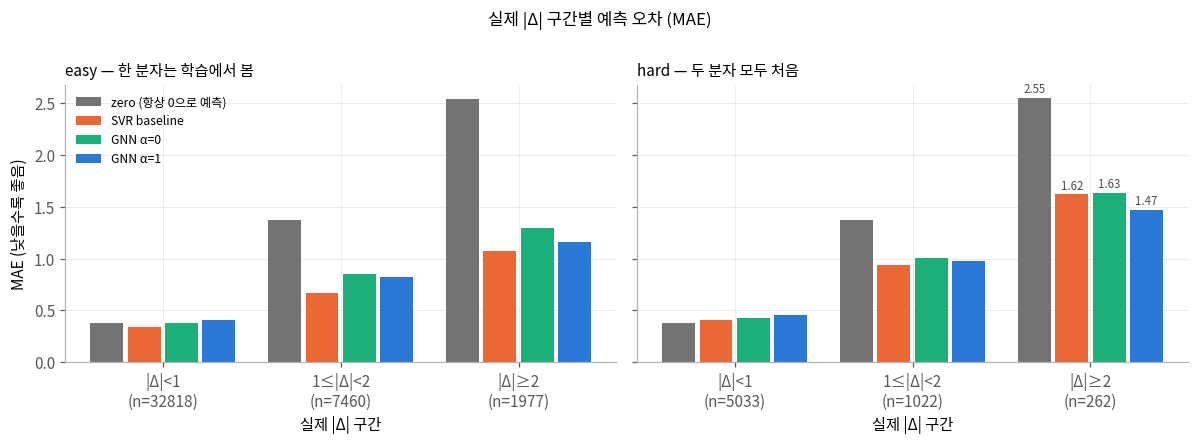

In [29]:
BUCKETS = ['|Δ|<1', '1≤|Δ|<2', '|Δ|≥2']
LBL = {'zero': 'zero (항상 0으로 예측)', 'svr': 'SVR baseline', 'gnn_a0': 'GNN α=0', 'gnn_best': f'GNN α={BEST_ALPHA}'}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
w = 0.21
for a_, s, title in zip(ax, ['test_easy', 'test_hard'], ['easy — 한 분자는 학습에서 봄', 'hard — 두 분자 모두 처음']):
    for i, (m, c) in enumerate(zip(MODELS, [MUTED, C2, C3, C1])):
        v = [mae.loc[(s, b), m] for b in BUCKETS]
        a_.bar(np.arange(3) + (i - 1.5) * w, v, w * 0.88, color=c, label=LBL[m], zorder=2)
        if s == 'test_hard':   # 헤드라인 구간만 직접 라벨 (모든 막대에 숫자를 붙이지 않는다)
            a_.text(2 + (i - 1.5) * w, v[2] + 0.05, f'{v[2]:.2f}', ha='center', fontsize=7.5, color='0.3')
    a_.set(xticks=range(3), xlabel='실제 |Δ| 구간')
    a_.set_xticklabels([f'{b}\n(n={int(mae.loc[(s, b), "n"])})' for b in BUCKETS])
    a_.set_title(title, loc='left', fontsize=10); tidy(a_)
ax[0].set_ylabel('MAE (낮을수록 좋음)'); ax[0].legend(fontsize=8, frameon=False)
fig.suptitle('실제 |Δ| 구간별 예측 오차 (MAE)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

### non-cliff가 왜 기준선보다 나쁜가 — 과분산 진단

두 가지 가능성이 있다.

1. **방향이 틀렸다** — 예측과 실제의 상관이 약하다
2. **과분산** — 방향은 맞지만 크기를 너무 크게 말한다. Δ가 거의 0인 쌍에 큰 값을 얹어 오차를 키운다

실제값을 예측값에 회귀했을 때 기울기가 1보다 작으면 2번이다.
검증 세트로 축소 계수 하나만 맞춰 곱해보면, 스칼라 보정으로 해결되는 문제인지 알 수 있다.
**이건 진단이지 모델 변경이 아니다.**

In [30]:
diag = pd.DataFrame([dict(split=s, corr=float(np.corrcoef(d.pred_gnn_best, d.delta)[0, 1]),
                          slope=float(np.polyfit(d.pred_gnn_best, d.delta, 1)[0]),
                          std_pred=d.pred_gnn_best.std(), std_true=d.delta.std())
                     for s in ['test_easy', 'test_hard'] for d in [pairs[pairs.split == s]]]).set_index('split')
display(diag.round(3))

# val로 스칼라 축소 계수 하나만 최소제곱 적합 (절편 없음 — Δ̂ = 0은 "변화 없음"이라 그대로 둬야 한다)
v = pairs[pairs.split.str.startswith('val')]
SHRINK = float((v.delta * v.pred_gnn_best).sum() / (v.pred_gnn_best ** 2).sum())
pairs['pred_gnn_shrunk'] = SHRINK * pairs.pred_gnn_best
print(f'val로 맞춘 축소 계수 c = {SHRINK:.3f}  →  c·Δ̂ 로 바꿨을 때 test RMSE')
rmse_table(pairs[pairs.split.str.startswith('test')], 'pred_gnn_shrunk').round(3)

,corr,slope,std_pred,std_true
split,,,,
test_easy,0.650,0.832,0.711,0.91
test_hard,0.509,0.647,0.691,0.88


val로 맞춘 축소 계수 c = 0.816  →  c·Δ̂ 로 바꿨을 때 test RMSE


is_cliff,cliff,non-cliff,all
split,,,
test_easy,1.138,0.493,0.691
test_hard,1.311,0.546,0.766


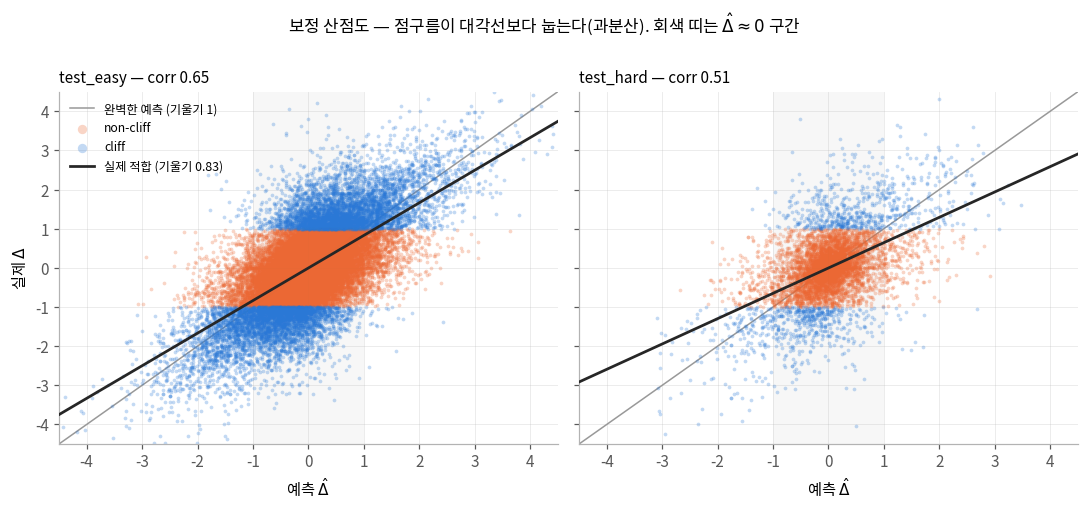

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
LIM = 4.5
for a_, s in zip(ax, ['test_easy', 'test_hard']):
    d = pairs[pairs.split == s]
    a_.plot([-LIM, LIM], [-LIM, LIM], color='0.6', lw=1, zorder=1, label='완벽한 예측 (기울기 1)')
    for cl, c, lbl in [(False, C2, 'non-cliff'), (True, C1, 'cliff')]:
        m = (d.is_cliff == cl).values
        a_.scatter(d.pred_gnn_best[m], d.delta[m], s=6, alpha=0.28, color=c, lw=0, zorder=2, label=lbl)
    sl, ic = np.polyfit(d.pred_gnn_best, d.delta, 1)
    xs = np.array([-LIM, LIM])
    a_.plot(xs, sl * xs + ic, color='0.15', lw=1.8, zorder=3, label=f'실제 적합 (기울기 {sl:.2f})')
    a_.axvspan(-1, 1, color='0.5', alpha=0.06, lw=0, zorder=0)
    a_.set(xlim=(-LIM, LIM), ylim=(-LIM, LIM), xlabel=r'예측 $\hat{\Delta}$')
    a_.set_title(f'{s} — corr {np.corrcoef(d.pred_gnn_best, d.delta)[0, 1]:.2f}', loc='left', fontsize=10)
    tidy(a_)
ax[0].set_ylabel(r'실제 $\Delta$')
h_, l_ = ax[0].get_legend_handles_labels()
ax[0].legend(h_, l_, fontsize=8, frameon=False, loc='upper left', markerscale=2.5)
fig.suptitle(r'보정 산점도 — 점구름이 대각선보다 눕는다(과분산). 회색 띠는 $\hat{\Delta}\approx0$ 구간', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

## 12. 결과 해석 (2026-09-23, MoleculeACE 30개 타깃 전체)

평가 쌍 153,969개 · 학습 쌍 349,565개 · **α 5개 × 시드 3개 = 15회 학습**

### 한 줄 요약
**모델 비교가 처음으로 가능해졌고(시드 편차 붕괴) α의 역할도 곡선으로 드러났다.
다만 쌍 모델은 어떤 α에서도 baseline에 못 미치고, non-cliff에서는 "항상 0"에도 못 미친다.**

### 1. 시드 편차가 무너졌다 — 가장 큰 진전

4개 타깃에서는 **같은 설정·같은 시드로 두 번 돌려도 결론이 뒤집혔다**
(test hard cliff 1.160 → 1.362, baseline은 1.256). 30개 타깃에서는 시드 폭이 **0.006 ~ 0.073**으로 줄어
모델 간 격차가 폭보다 커졌다.

데이터 12.7배 확대가 성능이 아니라 **재현성**에 먼저 효과를 냈다.
성능 결과가 아니라 **방법론 결과**다 — activity cliff 예측 논문들이 대개 시드 1개로 모델을 비교하는데,
그 조건에서는 결론이 실행마다 뒤집힐 수 있다.

### 2. ② 손실(cliff 가중): 곡선에 내부 최적점이 있다

| α | 검증 cliff | 검증 non-cliff |
|---|---|---|
| 0 | 1.163 | **0.518** |
| 0.5 | 1.142 | 0.546 |
| **1** | **1.135** | 0.559 |
| 2 | 1.136 | 0.582 |
| 4 | 1.155 | 0.596 |

**α = 4는 열등하다** — α=1보다 cliff도 non-cliff도 나쁘다. 쓸모 있는 구간은 **α ∈ [0, 2]** 다.

평가 세트에서는 효과가 더 선명하다 (시드 3개 범위, test hard):

| α | 0 | 0.5 | 1 | 2 | 4 |
|---|---|---|---|---|---|
| cliff | 1.324~1.358 | 1.300~1.329 | **1.276~1.286** | 1.239~1.311 | 1.299~1.314 |
| non-cliff | **0.572~0.578** | 0.590~0.621 | 0.611~0.631 | 0.637~0.647 | 0.638~0.665 |

α=0과 α=1의 cliff 구간이 **겹치지 않고**, non-cliff는 **단조롭게 나빠진다.**
가중 손실이 의도한 교환을 만든다는 것이 재현 가능하게 확인됐다.

**그러나 곡선 전체가 "항상 0" 선의 오른쪽에 있다.** 어떤 α를 골라도 non-cliff에서는 그보다 나쁘고,
baseline은 곡선 전체를 양축에서 압도한다. **α 조정만으로는 격차를 좁힐 수 없다.**

### 3. 냉정하게: 아직 baseline에 진다 (α=1, 시드 3개 평균)

| test split | | zero | SVR | GNN α=0 | GNN α=1 |
|---|---|---|---|---|---|
| easy | cliff | 1.720 | **0.928** | 1.120 | 1.079 |
| | non-cliff | 0.465 | **0.447** | 0.507 | 0.549 |
| hard | cliff | 1.715 | **1.256** | 1.339 | 1.282 |
| | non-cliff | **0.470** | 0.524 | 0.576 | 0.618 |

가장 가까운 칸이 test hard cliff로 **격차 0.026**(시드 폭 0.010) — 좁지만 폭보다 커서 동률이 아니라 열세다.

**non-cliff에서는 "항상 0"이 baseline보다도 낫다**(0.470 vs 0.524).
`|Δ| < 1`에는 구조만으로 읽어낼 신호가 사실상 없다는 뜻이고,
그렇다면 목표는 **"이기는 것"이 아니라 "지지 않는 것"** 이어야 한다.

### 4. |Δ| 구간별 MAE — 강점은 한 칸으로 좁혀졌다

| test split | 구간 | n | zero | SVR | GNN α=0 | GNN α=1 |
|---|---|---|---|---|---|---|
| easy | \|Δ\|<1 | 32,818 | 0.376 | **0.336** | 0.382 | 0.411 |
| | 1≤\|Δ\|<2 | 7,460 | 1.376 | **0.670** | 0.850 | 0.819 |
| | \|Δ\|≥2 | 1,977 | 2.537 | **1.075** | 1.291 | 1.163 |
| hard | \|Δ\|<1 | 5,033 | **0.383** | 0.404 | 0.428 | 0.458 |
| | 1≤\|Δ\|<2 | 1,022 | 1.376 | **0.934** | 1.008 | 0.976 |
| | \|Δ\|≥2 | 262 | 2.550 | 1.620 | 1.631 | **1.472** |

**hard의 `|Δ| ≥ 2`에서만 앞선다**(1.472 vs 1.620, 9%).
분자별로 예측해 빼는 방식은 두 예측이 모두 평균으로 끌려가 큰 차이를 못 만든다.
**쌍 모델의 이점은 "양쪽 다 모르고, 차이가 클 때" 나온다.**

### 5. 과적합은 더 이상 병목이 아니다
검증/학습 RMSE 비가 **5.0 → 1.9 → 약 1.4**로 줄었다 (학습 쌍 6,175 → 27,543 → 349,565).

### 6. 남은 병목: 과분산 — 전역 축소로는 못 고친다

| test split | 상관 | 기울기 | 예측 std | 실제 std |
|---|---|---|---|---|
| easy | 0.650 | 0.832 | 0.711 | 0.910 |
| hard | 0.509 | **0.647** | 0.691 | 0.880 |

hard에서 상관이 0.509인데 기울기가 0.647 — **상관이 정당화하는 것보다 크게 말한다.**
축소 계수(0.816)를 곱하면 non-cliff는 0.611 → 0.546으로 좋아지지만 cliff가 1.286 → 1.311로 악화된다.

non-cliff 오차의 대부분은 **오경보**(예측은 큰데 실제로는 평평한 쌍)다.
예측값의 단조 함수로는 오경보와 진짜 cliff를 구분할 수 없어, 오경보를 줄이면 진짜 cliff도 같이 줄어든다.
**쌍마다 확신도를 다르게 주는 장치가 필요하다.**

### 7. 그 밖에
- **양방향 평균**: 역방향 증강이 이미 반대칭을 가르쳐 소수점 셋째 자리만 바뀐다. 대조군으로 남긴다
- **타깃별**: 30개 중 11개에서만 앞선다(α=2일 때는 14개 — 타깃별 순위도 α에 흔들린다). 학습 쌍 수와 단조 관계는 없다
- **치환기 크기**: 바뀐 부분이 클수록 cliff가 되기 쉽다(≤10%에서 16.6%, >30%에서 33.8%).
  ACGCN의 20% 제한을 걸면 쌍의 53.3%만 남고 쉬운 쪽에 치우치므로 걸지 않는다

### 결론

| | 상태 |
|---|---|
| 시드 편차 붕괴 → 모델 비교 가능 | ✅ |
| ② cliff 가중이 교환을 만든다 (내부 최적 α≈1, α=4는 열등) | ✅ |
| 과적합 감소 (5.0 → 1.4) | ✅ |
| hard `\|Δ\|≥2`에서 baseline 대비 우위 (1.472 vs 1.620) | ✅ |
| **그 외 전 구간에서 baseline에 열세** | ❌ |
| **어떤 α에서도 non-cliff가 "항상 0"보다 나쁘다** | ❌ |

### 다음 단계
1. **cliff 게이트** — 6번 과분산에 대한 답이자, 2번에서 "α로는 못 넘는다"고 확인된 벽을 넘는 수단.
   "이 쌍이 cliff인가"를 판정하는 헤드를 붙여 그 확률만큼 예측 크기를 줄인다.
   평평할 것 같은 쌍만 0으로 눌러 non-cliff를 기준선 수준으로 되돌리고 cliff는 유지하는 것이 목표.
   baseline이 구조적으로 공짜로 얻는 보수성을 학습으로 만드는 셈이다.
   **목표: test hard non-cliff ≤ 0.53(현재 0.611), cliff ≤ 1.28 유지**
2. **③ 설명** — 게이트가 붙으면 "왜 cliff라고 판단했나"로 자연스럽게 이어진다
3. **이웃 기준점으로 절대 활성값 복원** → 원 논문 수치와 직접 비교